<figure style="text-align: left; margin: 1em 0; float: right">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/55/ImmoScout24_Logo_2020.svg/960px-ImmoScout24_Logo_2020.svg.png" alt="ImmoScout24 Logo" width="500">
    <figcaption style="font-size: 0.85em; color: #555555; margin-top: 0.6em; font-family: sans-serif; line-height: 1.4;">
        <p>Abbildung 1: Immobilien Scout GmbH (2020). </p>
        <p><i>Unternehmenslogo ImmoScout24</i> [Grafik]. Verfügbar unter: </p>
        <a href="https://www.immobilienscout24.de/redesign/images/footer/Scout24_IMMO_Logo_Stacked_Solid_w3000px_RGB.svg" style="color: #1fc0cf; text-decoration: none;">https://www.immobilienscout24.de/redesign/images/footer/Scout24_IMMO_Logo_Stacked_Solid_w3000px_RGB.svg</a>
        <p>[Abgerufen am 18 Mai 2026].</p>
    </figcaption>
</figure>

# Datenbereinigung des Datasets __[Apartment rental offers in Germany](https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany)__

## Inhaltsverzeichnis

### [Projektkontext & Zielsetzung](#projektkontext)
### [1. Importierung von Libraries](#libraries)
### [2. Importierung des Datasets](#dataset)
### [3. Erster Überblick](#ueberblick)
### [4. Datenbereinigung und Visualisierungsanalyse der Features](#bereinigung)

<div style="padding-left: 2em;">

#### [4.4.1 Kaltmiete (`baseRent`)](#miete)
#### [4.4.2 Etage (`floor`) & Anzahl der Stockwerke (`numberOfFloors`)](#etage)
#### [4.4.3 Wohnfläche (`livingSpace`)](#flaeche)
#### [4.4.4 Sanierungsjahr (`lastRefurbish`)](#sanierung)
#### [4.4.5 Multivariate Ausreißererkennung (Isolation Forest)](#isolationforest)
#### [4.4.6 Log-transformierte IQR-Filterung](#logiqr)

</div>

### [5. Korrelationsanalyse](#korrelation)
### [6. Feature Selection](#features)
### [7. Datenexport](#export)



## Projektkontext & Zielsetzung

Im Rahmen dieser Arbeit werden folgende zentrale Forschungsfragen (FF) beantwortet:
1. **FF 1 (Feature Importance):** Welche Merkmale (Features) einer Wohnung haben den größten Einfluss auf die Kaltmiete (`baseRent`) in Deutschland?
2. **FF 2 (Preprocessing):** Wie wirken sich methodische Entscheidungen im Preprocessing (z. B. Outlier-Detection, Imputation fehlender Werte, Feature-Selection) auf die Modellqualität aus?
3. **FF 3 (Modellierung):** Welcher Modellierungsansatz liefert die höchste Vorhersagegenauigkeit für Mietpreise (`baseRent`)?

**Dieses Notebook:**
Dieses Notebook bildet das Fundament der Datenanalyse. Der Fokus liegt auf der **Vorbereitung für FF 2** (Erste Bereinigungs- und Imputationsschritte) sowie der Erstellung eines konsistenten Datensatzes, der als Grundlage für **FF 1** und **FF 3** dient.

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">
<div style="text-decoration: underline;">
    
## 1. Importierung von Libraries
</div>

Von Kaggle bereits importierte Libraries, wie numpy und pandas um das Dataset zu analysieren und manipulieren.
Matpotlib wurde außerdem importiert um Graphiken darzustellen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy.stats import chi2_contingency
import missingno as msno
from sklearn.ensemble import IsolationForest #Für Ausreißer

!pip install pyampute
from pyampute.exploration.mcar_statistical_tests import MCARTest #Prüfung auf MCAR

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">


<div style="text-decoration: underline;">
    
## 2. Importierung des Datasets
</div>


### Quelle und Erhebung
Der Datensatz **[Apartment rental offers in Germany](https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany)** wurde von Corrie Bartelheimer [(`@corrieaar`)](https://www.kaggle.com/corrieaar) auf Kaggle bereitgestellt. Das Projekt umfasst eine "Temporal Coverage" (zeitliche Abdeckung) vom **23.09.2018 bis zum 09.10.2019** und bezieht sich geografisch auf **Deutschland**.
Das Dataset sollte auch Jährlich aktualisiert werden, mit der letzten Aktualisierung vor 6jahren (stand 19.05.2026)

Die Daten wurden von der Plattform **[ImmoScout24](https://www.immobilienscout24.de/)** extrahiert. Es wurden die Inserate "gescraped" und es liegen Daten vor für einen Zeitraum von:
* **Sep.2018**
* **Feb.2020**

In [7]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("corrieaar/apartment-rental-offers-in-germany")


file_path = os.path.join(path, "immo_data.csv")
original_df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'apartment-rental-offers-in-germany' dataset.


In [8]:
df = original_df.copy()

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">


<div style="text-decoration: underline;">

##  3. Erster Überblick
</div>

### 3.1. Struktur des Datensatzes
Das Dataset enthält die Daten von insgesamt **268.850 Inseraten** (Mietwohnungen) und besitzt im Originalzustand **49 Features** (Spalten).
Das Dataset setzt sich aus Features mit `object`, `float64`, `int64` und `bool` werten zusammen.

| Feature / Spaltenname | Datentyp | Fehlende Werte (Absolut) | Fehlende Werte (in %) |
| :--- | ---: | ---: | ---: |
| `telekomHybridUploadSpeed` | float64 | 223.830 | 83.25% |
| `electricityBasePrice` | float64 | 222.004 | 82.58% |
| `electricityKwhPrice` | float64 | 222.004 | 82.58% |
| `energyEfficiencyClass` | object | 191.063 | 71.07% |
| `lastRefurbish` | float64 | 188.139 | 69.98% |
| `heatingCosts` | float64 | 183.332 | 68.19% |
| `noParkSpaces` | float64 | 175.798 | 65.39% |
| `petsAllowed` | object | 114.573 | 42.62% |
| `interiorQual` | object | 112.665 | 41.91% |
| `thermalChar` | float64 | 106.506 | 39.62% |
| `numberOfFloors` | float64 | 97.732 | 36.35% |
| `houseNumber` | object | 71.018 | 26.42% |
| `streetPlain` | object | 71.013 | 26.41% |
| `condition` | object | 68.489 | 25.47% |
| `yearConstructed` | float64 | 57.045 | 21.22% |
| `yearConstructedRange` | float64 | 57.045 | 21.22% |
| `firingTypes` | object | 56.964 | 21.19% |
| `facilities` | object | 52.924 | 19.69% |
| `floor` | float64 | 51.309 | 19.08% |
| `heatingType` | object | 44.856 | 16.68% |
| `totalRent` | float64 | 40.517 | 15.07% |
| `typeOfFlat` | object | 36.614 | 13.62% |
| `telekomUploadSpeed` | float64 | 33.358 | 12.41% |
| `telekomTvOffer` | object | 32.619 | 12.13% |
| `description` | object | 19.747 | 7.34% |
| `serviceCharge` | float64 | 6.909 | 2.57% |
| `pricetrend` | float64 | 1.832 | 0.68% |
| `regio1` | object | 0 | 0.00% |
| `newlyConst` | bool | 0 | 0.00% |
| `balcony` | bool | 0 | 0.00% |
| `picturecount` | int64 | 0 | 0.00% |
| `scoutId` | int64 | 0 | 0.00% |
| `hasKitchen` | bool | 0 | 0.00% |
| `geo_bln` | object | 0 | 0.00% |
| `cellar` | bool | 0 | 0.00% |
| `baseRent` | float64 | 0 | 0.00% |
| `livingSpace` | float64 | 0 | 0.00% |
| `geo_krs` | object | 0 | 0.00% |
| `street` | object | 0 | 0.00% |
| `lift` | bool | 0 | 0.00% |
| `baseRentRange` | int64 | 0 | 0.00% |
| `geo_plz` | int64 | 0 | 0.00% |
| `noRooms` | float64 | 0 | 0.00% |
| `noRoomsRange` | int64 | 0 | 0.00% |
| `garden` | bool | 0 | 0.00% |
| `livingSpaceRange` | int64 | 0 | 0.00% |
| `regio2` | object | 0 | 0.00% |
| `regio3` | object | 0 | 0.00% |
| `date` | object | 0 | 0.00% |

In [6]:
df.head()

,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,NaN,False,False,6,4.62,10.0,...,Dortmund,Schüren,Die ebenerdig zu erreichende Erdgeschosswohnun...,Die Wohnung ist mit Laminat ausgelegt. Das Bad...,NaN,NaN,NaN,NaN,NaN,May19
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,NaN,False,True,8,3.47,10.0,...,Rhein_Pfalz_Kreis,Böhl_Iggelheim,Alles neu macht der Mai – so kann es auch für ...,NaN,NaN,NaN,2019.0,NaN,NaN,May19
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,10.0,True,True,8,2.72,2.4,...,Dresden,Äußere_Neustadt_Antonstadt,Der Neubau entsteht im Herzen der Dresdner Neu...,"* 9 m² Balkon\n* Bad mit bodengleicher Dusche,...",NaN,NaN,NaN,NaN,NaN,Oct19
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,NaN,False,True,9,1.53,40.0,...,Mittelsachsen_Kreis,Freiberg,Abseits von Lärm und Abgasen in Ihre neue Wohn...,NaN,87.23,NaN,NaN,NaN,NaN,May19
4,Bremen,138.00,self_contained_central_heating,NaN,NaN,False,True,19,2.46,NaN,...,Bremen,Neu_Schwachhausen,Es handelt sich hier um ein saniertes Mehrfami...,Diese Wohnung wurde neu saniert und ist wie fo...,NaN,NaN,NaN,NaN,NaN,Feb20


In [9]:
df.shape

(268850, 49)

In [ ]:
df.dtypes

regio1                       object
serviceCharge               float64
heatingType                  object
telekomTvOffer               object
telekomHybridUploadSpeed    float64
newlyConst                     bool
balcony                        bool
picturecount                  int64
pricetrend                  float64
telekomUploadSpeed          float64
totalRent                   float64
yearConstructed             float64
scoutId                       int64
noParkSpaces                float64
firingTypes                  object
hasKitchen                     bool
geo_bln                      object
cellar                         bool
yearConstructedRange        float64
baseRent                    float64
houseNumber                  object
livingSpace                 float64
geo_krs                      object
condition                    object
interiorQual                 object
petsAllowed                  object
street                       object
streetPlain                 

In [ ]:
df['date'].min()

'Feb20'

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

### 3.2. Ad-hoc-Analyse der numerischen Features

Im Folgenden wird eine Ad-hoc-Analyse durchgeführt, um die numerischen Features, mit ungewöhnlichen Minimum und Maximumwerten aufzuzeigen.


| Feature (Numerisch) | Minimum | Maximum | Analytisches Urteil & Mögliche Ursache |
| :--- | ---: | ---: | :--- |
| `baseRent` (Kaltmiete) | 0,00 | 9.999.999,00 | **Extreme Ausreißer und Fehler:** 0 € Miete ist unplausibel. Fast 10 Mio. € ist unrealistisch und kann zu großen Ausreißern führen. |
| `totalRent` (Warmmiete) | 0,00 | 15.751.540,00 | **Extreme Ausreißer und Fehler:** Gleiches Problem wie bei der Kaltmiete. |
| `livingSpace` (Wohnfläche) | 0,00 | 111.111,00 | **Extreme Ausreißer und Fehler:** Eine Wohnfläche von 0 m² ist unmöglich. Der Maximalwert von 111.111,00 m² ist sehr unwahrscheinlich und würde zu Ausreißern führen. |
| `noRooms` (Zimmeranzahl) | 0,00 | 999,99 | **Extreme Ausreißer und Fehler:** 0 Zimmer ist zwar theoretisch möglich, kann sich aber auch mit Eingabefehlern überschneiden. Ein Wert von 999,99 deutet auf einen Fehler hin, da es sich hier nicht um absolute Zahlen handelt und es ein viel zu starker Ausreißer wäre. |
| `serviceCharge` (Nebenkosten) | 0,00 | 146.118,00 | **Extreme Ausreißer:** Nebenkosten von über 140.000 € im Monat für eine Wohnung sind sehr ungewöhnlich und können zu starken Ausreißern führen. |
| `heatingCosts` (Heizkosten) | 0,00 | 12.613,00 | **Ausreißer:** Über 12.000 € Heizkosten monatlich sind unrealistisch hoch für normale Wohnungs-Inserate. |
| `yearConstructed` (Baujahr) | 1.000,00 | 2.090,00 | **Logikfehler:** Ein Baujahr im Jahr 1000 ist historisch bei modernen Wohnungsbörsen extrem unwahrscheinlich. Ein Baujahr 2090 liegt weit in der Zukunft (Datensatz endet 2019!). |
| `floor` (Etage) / `numberOfFloors` | -1,00 | 999,00 | **Logikfehler:** Die Werte `-1` (Keller) sind teils plausibel, aber `999` Etagen sind zu starke Ausreißer. |
| `noParkSpaces` (Stellplätze) | 0,00 | 2.241,00 | **Eingabefehler:** Über 2.000 Parkplätze für eine einzelne Mietwohnung ist unrealistisch. Hier wurden vielleicht alle öffentlich zugänglichen Parkplätze aufgezählt oder ein Tippfehler erfasst. |

In [ ]:
df.describe()

,serviceCharge,telekomHybridUploadSpeed,picturecount,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,scoutId,noParkSpaces,yearConstructedRange,...,noRooms,thermalChar,floor,numberOfFloors,noRoomsRange,livingSpaceRange,heatingCosts,lastRefurbish,electricityBasePrice,electricityKwhPrice
count,261941.000000,45020.0,268850.000000,267018.000000,235492.000000,2.283330e+05,211805.000000,2.688500e+05,93052.000000,211805.000000,...,268850.000000,162344.000000,217541.000000,171118.000000,268850.000000,268850.000000,85518.000000,80711.000000,46846.000000,46846.000000
mean,151.206113,10.0,9.791958,3.389001,28.804928,9.013315e+02,1966.400590,1.069697e+08,1.327634,3.714544,...,2.641261,114.749533,2.122405,3.572319,2.571542,3.070790,76.990866,2013.904536,89.113612,0.199769
std,308.295790,0.0,6.408399,1.964874,16.337151,3.323833e+04,46.992207,1.250093e+07,8.361403,2.738134,...,2.633440,61.653663,3.634934,6.375496,0.937594,1.407127,147.716278,10.963125,5.395805,0.009667
min,0.000000,10.0,0.000000,-12.330000,1.000000,0.000000e+00,1000.000000,2.887174e+07,0.000000,1.000000,...,1.000000,0.100000,-1.000000,0.000000,1.000000,1.000000,0.000000,1015.000000,71.430000,0.170500
25%,95.000000,10.0,6.000000,2.000000,10.000000,4.698000e+02,1950.000000,1.066910e+08,1.000000,1.000000,...,2.000000,79.000000,1.000000,2.000000,2.000000,2.000000,54.000000,2012.000000,90.760000,0.191500
50%,135.000000,10.0,9.000000,3.390000,40.000000,6.500000e+02,1973.000000,1.111584e+08,1.000000,3.000000,...,3.000000,107.000000,2.000000,3.000000,3.000000,3.000000,70.000000,2017.000000,90.760000,0.198500
75%,190.000000,10.0,13.000000,4.570000,40.000000,9.850000e+02,1996.000000,1.137688e+08,1.000000,5.000000,...,3.000000,140.300000,3.000000,4.000000,3.000000,4.000000,90.000000,2019.000000,90.760000,0.205500
max,146118.000000,10.0,121.000000,14.920000,100.000000,1.575154e+07,2090.000000,1.157117e+08,2241.000000,9.000000,...,999.990000,1996.000000,999.000000,999.000000,5.000000,7.000000,12613.000000,2919.000000,90.760000,0.227600


In [ ]:
total_rows = len(df)
missing_percentage = (df.isnull().sum() / total_rows) * 100
missing_percentage

regio1                       0.000000
serviceCharge                2.569834
heatingType                 16.684397
telekomTvOffer              12.132788
telekomHybridUploadSpeed    83.254603
newlyConst                   0.000000
balcony                      0.000000
picturecount                 0.000000
pricetrend                   0.681421
telekomUploadSpeed          12.407662
totalRent                   15.070485
yearConstructed             21.218151
scoutId                      0.000000
noParkSpaces                65.388879
firingTypes                 21.188023
hasKitchen                   0.000000
geo_bln                      0.000000
cellar                       0.000000
yearConstructedRange        21.218151
baseRent                     0.000000
houseNumber                 26.415473
livingSpace                  0.000000
geo_krs                      0.000000
condition                   25.474800
interiorQual                41.906267
petsAllowed                 42.615957
street      

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

<div style="text-decoration: underline;">

## 4. Datenbereinigung und Visualisierungsanalyse der Features
</div>

### 4.1. Erste Feature Selection

Es werden `picturecount`, `scoutId`, `yearConstructedRange`, `houseNumber`, `street`, `streetPlain`, `baseRentRange`, `noRoomsRange`, `livingSpaceRange`, `description`, `facilities` und `date` aussortiert.

| Auszusortierendes Feature | Datentyp | Wissenschaftliche Begründung |
| :--- | ---: | :--- |
| `scoutId` | int64 | Es handelt sich um eine von ImmoScout24 generierte Inserats-ID. Da in unserem DataFrame bereits der Index als eindeutige ID fungiert, würde dies zu einer Redundanz führen. Zudem wurden vorab keine Duplikate gefunden, was zeigt, dass sich kein Inserat zu zwei verschiedenen Erhebungszeitpunkten gleichzeitig im Datensatz befand. |
| `date` | object | Enthält für die Kernanalyse irrelevante Daten, da der exakte Erhebungszeitpunkt Vermietern bei der Preisfindung kaum weiterhilft. Für eine fundierte Trendanalyse weist dieses Feature zudem zu wenig Variabilität und zeitliche Tiefe auf. |
| `houseNumber` | object | Würde zu viel Rauschen (*Noise*) in den Daten erzeugen. Anhand einer spezifischen Hausnummer lassen sich keine robusten, verallgemeinerbaren Muster für ein Preismodell ableiten. |
| `street` | object | Zu spärlich besetzt. Das Feature wäre erst bei einem deutlich größeren Datensatz interessant, um die Mikro-Lage der Immobilie präziser zu fixieren. |
| `streetPlain` | object | Analog zu `street`, stellt lediglich eine andere Textformatierung der Straßennamen dar und ist somit redundant. |
| `description` | object | Unstrukturierter Freitext aus dem Inserat. Ohne den Einsatz von Natural Language Processing (NLP) ist dieses Feature für die quantitative Analyse nicht nutzbar. |
| `facilities` | object | Beschreibungstext der Ausstattung. Könnte zwar prinzipiell via NLP erschlossen werden, dies liegt jedoch außerhalb des definierten Ziels dieser Analyse. |
| `picturecount` | int64 | Die Anzahl der Bilder kann zwar dem Online-Marketing-Erfolg korrelieren, allerdings können  die Limits von Plattform zu Plattform variieren. Es wird ein konservativer Ansatz gewählt, der die Miete rein auf Basis der physischen Objekteigenschaften vor der Inserierung prognostiziert. |
| `yearConstructedRange` | float64 | Eine künstliche Kategorisierung des Baujahres. Das echte Baujahr (`yearConstructed`) liefert dem Modell weitaus präzisere, kontinuierliche Daten. |
| `baseRentRange` | int64 | Korreliert naturgemäß fast perfekt mit `baseRent`, unserer Zielvariable, und würde bei direkter Verwendung im Modell zu *Data Leakage* führen. Das Feature wird daher **nicht** in dieser ersten Selektion entfernt, sondern zunächst **vorübergehend beibehalten**: Es dient in Abschnitt 4 als Gruppierungsvariable für die medianbasierte Imputation fehlender Werte und wird erst unmittelbar vor der Korrelationsanalyse (Abschnitt 5) endgültig aus dem Datensatz entfernt. |
| `livingSpaceRange` | int64 | Künstliche Einteilung der Wohnfläche in Klassen. Angesichts der beachtlichen Größe des Datensatzes ist das detailliertere, kontinuierliche Feature `livingSpace` mathematisch wertvoller. |
| `noRoomsRange` | int64 | Künstliche Klasseneinteilung der Zimmeranzahl. Redundant, da direkt die präzisen, diskreten Werte aus `noRooms` genutzt werden. Die zusätzliche Beibehaltung der Ranges könnte zudem zu *Overfitting* führen. |

In [ ]:
# Beibehaltung relevanter Features basierend auf Begründung (siehe Markdown 4.1).
# Auskommentierte Spalten (z.B. 'picturecount', 'scoutId') werden fallengelassen.
df = df[['regio1',
         'serviceCharge',
         'heatingType', 'telekomTvOffer',
       'newlyConst', 'balcony',
         #'picturecount',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
       #'scoutId',
         'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar',
         #'yearConstructedRange',
         'baseRent',
         #'houseNumber',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
       #'street', 'streetPlain',
         'lift',
         'baseRentRange',
         'typeOfFlat',
       'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
       #'noRoomsRange',
         'garden',
         #'livingSpaceRange',
         'regio2', 'regio3',
       #'description', 'facilities',
         'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice',
         #'date'
        ]].copy()

In [ ]:
df.head()

,regio1,serviceCharge,heatingType,telekomTvOffer,newlyConst,balcony,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,...,floor,numberOfFloors,garden,regio2,regio3,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,False,False,4.62,10.0,840.0,1965.0,...,1.0,3.0,True,Dortmund,Schüren,NaN,NaN,NaN,NaN,NaN
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,False,True,3.47,10.0,NaN,1871.0,...,NaN,NaN,False,Rhein_Pfalz_Kreis,Böhl_Iggelheim,NaN,NaN,2019.0,NaN,NaN
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,True,True,2.72,2.4,1300.0,2019.0,...,3.0,4.0,False,Dresden,Äußere_Neustadt_Antonstadt,NaN,NaN,NaN,NaN,NaN
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,False,True,1.53,40.0,NaN,1964.0,...,3.0,NaN,False,Mittelsachsen_Kreis,Freiberg,87.23,NaN,NaN,NaN,NaN
4,Bremen,138.00,self_contained_central_heating,NaN,False,True,2.46,NaN,903.0,1950.0,...,1.0,NaN,False,Bremen,Neu_Schwachhausen,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isna().sum()

regio1                        0
serviceCharge              6909
heatingType               44856
telekomTvOffer            32619
newlyConst                    0
balcony                       0
pricetrend                 1832
telekomUploadSpeed        33358
totalRent                 40517
yearConstructed           57045
noParkSpaces             175798
firingTypes               56964
hasKitchen                    0
geo_bln                       0
cellar                        0
baseRent                      0
livingSpace                   0
geo_krs                       0
condition                 68489
interiorQual             112665
petsAllowed              114573
lift                          0
baseRentRange                 0
typeOfFlat                36614
geo_plz                       0
noRooms                       0
thermalChar              106506
floor                     51309
numberOfFloors            97732
garden                        0
regio2                        0
regio3  

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

### 4.2. Duplikat behandlung
Es wurden 2.111 duplikate entdeckt und entfernt.

In [ ]:
#Duplikate überprüfen
df.loc[df.duplicated()].head()

,regio1,serviceCharge,heatingType,telekomTvOffer,newlyConst,balcony,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,...,floor,numberOfFloors,garden,regio2,regio3,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice
2811,Sachsen,220.00,central_heating,ONE_YEAR_FREE,False,False,3.28,10.0,678.00,1920.0,...,NaN,NaN,False,Leipzig,Mockau_Süd,NaN,NaN,1993.0,NaN,NaN
3114,Sachsen,121.00,central_heating,ONE_YEAR_FREE,False,False,-0.20,40.0,371.00,NaN,...,1.0,NaN,True,Chemnitz,Hilbersdorf,NaN,NaN,NaN,NaN,NaN
7555,Sachsen,76.00,central_heating,ONE_YEAR_FREE,False,False,1.72,40.0,485.00,1989.0,...,4.0,4.0,False,Bautzen_Kreis,Kamenz,77.0,NaN,2018.0,NaN,NaN
9410,Sachsen,260.00,district_heating,ONE_YEAR_FREE,True,True,2.78,40.0,1295.00,2019.0,...,1.0,NaN,True,Leipzig,Böhlitz_Ehrenberg,NaN,B,NaN,NaN,NaN
11021,Brandenburg,166.92,NaN,ONE_YEAR_FREE,False,True,0.00,40.0,505.96,1978.0,...,3.0,NaN,False,Cottbus,Spremberger_Vorstadt,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.drop_duplicates().copy()
df.loc[df.duplicated()]

,regio1,serviceCharge,heatingType,telekomTvOffer,newlyConst,balcony,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,...,floor,numberOfFloors,garden,regio2,regio3,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice


In [ ]:
df.shape

(266737, 37)

In [ ]:
df.head()

,regio1,serviceCharge,heatingType,telekomTvOffer,newlyConst,balcony,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,...,floor,numberOfFloors,garden,regio2,regio3,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,False,False,4.62,10.0,840.0,1965.0,...,1.0,3.0,True,Dortmund,Schüren,NaN,NaN,NaN,NaN,NaN
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,False,True,3.47,10.0,NaN,1871.0,...,NaN,NaN,False,Rhein_Pfalz_Kreis,Böhl_Iggelheim,NaN,NaN,2019.0,NaN,NaN
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,True,True,2.72,2.4,1300.0,2019.0,...,3.0,4.0,False,Dresden,Äußere_Neustadt_Antonstadt,NaN,NaN,NaN,NaN,NaN
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,False,True,1.53,40.0,NaN,1964.0,...,3.0,NaN,False,Mittelsachsen_Kreis,Freiberg,87.23,NaN,NaN,NaN,NaN
4,Bremen,138.00,self_contained_central_heating,NaN,False,True,2.46,NaN,903.0,1950.0,...,1.0,NaN,False,Bremen,Neu_Schwachhausen,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.reset_index(drop=True).copy()

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

### 4.3. Geografieanalyse

Es liegen insgesamt sechs Geografie-Features vor, welche analysiert werden, um ein potenzielles Overfitting zu beseitigen.

Einige dieser Features beinhalten redundante Informationen. Für die Analyse wird jeweils das Feature ausgewählt, welches im Namensschema eine eindeutigere Zuordnung erlaubt oder mathematisch robuster ist:

* **`geo_bln` vs. `regio1` (Bundesländer):**
  Hier wird `geo_bln` gewählt. Es sind alle 16 Bundesländer im Datensatz vorhanden.
* **`geo_krs` vs. `regio2` (Städte / Landkreise):**
  Hier wird `geo_krs` gewählt. Im Datensatz befinden sich 419 einzigartige Werte. In Deutschland existieren offiziell jedoch nur 294 Landkreise sowie 107 kreisfreie Städte (insgesamt 401). Eine nähere Überprüfung mittels *Regular Expressions* (RegEx) zeigt, dass diese Werte valide sind. Die Differenz von 18 zusätzlichen Einträgen resultiert vermutlich aus plattforminternen, spezifisch durch ImmoScout24 definierten Kreisregionen, da es im relevanten Zeitraum keine umfassenden Kreisreformen gab und die offizielle Summe der Kreise unverändert blieb.

#### Spezifische Feature-Analyse der feineren Ebenen:

* **`regio3` (Stadtteil / Gemeinden):**
  Dieses Feature wird für das finale Modell ausgeschlossen. Der Datensatz deckt Deutschland in der Tiefe nicht vollständig ab: Während es bundesweit rund 10.796 (2020) Gemeinden und Stadtteile gibt, sind im Datensatz nur 8.684 einzigartige Werte vorhanden. Das bedeutet, dass über 2.000 Gemeinden und Stadtteile überhaupt nicht im Datensatz auftauchen. Für diese fehlenden Regionen könnte das Modell später keinerlei Vorhersagen treffen.
* **`geo_plz` (Postleitzahl):**
  Die Postleitzahl wird ebenfalls nicht als Feature verwendet. Mit 7.634 einzigartigen Werten (bei insgesamt ca. 8.181 Ortspostleitzahlen in Deutschland) ist die Kardinalität zu hoch, was das Risiko für ein Overfitting des Regressionsmodells drastisch erhöht. Zudem hat das Feature über 500 Postleitzahlen die im Datensatz vollständig fehlen. Das Modell könnte für diese unberücksichtigten Postregionen später keinerlei valide Vorhersagen treffen.

*Quellen:*
* [Wikipedia: Gemeinden in Deutschland](https://de.wikipedia.org/wiki/Gemeinde_(Deutschland))
* [Die Bundeswahlleiterin: Kreise und kreisfreie Städte (2019)](https://www.bundeswahlleiterin.de/europawahlen/2019/kreise.html)
* [Wikipedia: Kreisreformen in Deutschland nach 1990](https://de.wikipedia.org/wiki/Kreisreformen_in_Deutschland_nach_1990)
* [Deutsche Post DHL Group: 25 Jahre fünfstellige Postleitzahlen](https://group.dhl.com/de/presse/pressemitteilungen/2018/25-jahre-fuenfstellige-postleitzahlen-in-deutschland.html)

In [ ]:
df['regio1'].value_counts()

regio1
Nordrhein_Westfalen       62574
Sachsen                   57390
Bayern                    21516
Sachsen_Anhalt            19902
Hessen                    17665
Niedersachsen             16524
Baden_Württemberg         16036
Berlin                    10290
Thüringen                  8324
Rheinland_Pfalz            8311
Brandenburg                6892
Schleswig_Holstein         6617
Mecklenburg_Vorpommern     6598
Hamburg                    3726
Bremen                     2951
Saarland                   1421
Name: count, dtype: int64

In [ ]:
df['regio1'].nunique()

16

In [ ]:
df['regio2'].nunique()

419

In [ ]:
df['regio2'].value_counts()

regio2
Leipzig                         13538
Chemnitz                        12351
Berlin                          10290
Dresden                          7465
Magdeburg                        4813
                                ...  
Lichtenfels_Kreis                  31
Freyung_Grafenau_Kreis             29
Haßberge_Kreis                     24
Neustadt_a.d._Waldnaab_Kreis       16
Kronach_Kreis                      12
Name: count, Length: 419, dtype: int64

In [ ]:
df['regio2'].isna().sum()

np.int64(0)

In [ ]:
df['regio2'].value_counts().tail(10)

regio2
Weißenburg_Gunzenhausen_Kreis              40
Rhön_Grabfeld_Kreis                        39
Neustadt_a.d._Aisch_Bad_Windsheim_Kreis    36
Schwabach                                  35
Schweinfurt_Kreis                          35
Lichtenfels_Kreis                          31
Freyung_Grafenau_Kreis                     29
Haßberge_Kreis                             24
Neustadt_a.d._Waldnaab_Kreis               16
Kronach_Kreis                              12
Name: count, dtype: int64

In [ ]:
df['regio2'].str.replace('[-_., ]', '').str.lower().nunique()

419

In [ ]:
df['regio3'].value_counts().tail(1539)

regio3
Warnau                2
Eberfing              1
Wipfratal             1
Mörsfeld              1
Jembke                1
                     ..
Großvargula           1
Rehm_Flehde_Bargen    1
Blindheim             1
Hohenzieritz          1
Echem                 1
Name: count, Length: 1539, dtype: int64

In [ ]:
df['regio3'].nunique()

8684

In [ ]:
df['geo_plz'].nunique()

7634

In [ ]:
df['geo_krs'].nunique()

419

In [ ]:
df['geo_bln'].nunique()

16

In [ ]:
df['regio3'].value_counts()
df['geo_bln'].value_counts()

geo_bln
Nordrhein_Westfalen       62574
Sachsen                   57390
Bayern                    21516
Sachsen_Anhalt            19902
Hessen                    17665
Niedersachsen             16524
Baden_Württemberg         16036
Berlin                    10290
Thüringen                  8324
Rheinland_Pfalz            8311
Brandenburg                6892
Schleswig_Holstein         6617
Mecklenburg_Vorpommern     6598
Hamburg                    3726
Bremen                     2951
Saarland                   1421
Name: count, dtype: int64

In [ ]:
df = df[[
    #'regio1',
         'serviceCharge', 'heatingType', 'telekomTvOffer', 'newlyConst', 'balcony',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
         'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar',
         'baseRent',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
         'lift',
    'baseRentRange',
         'typeOfFlat',
       #'geo_plz',
    'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
         'garden',
         #'regio2', 'regio3',
         'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice',
        ]].copy()

In [ ]:
df.head()

,serviceCharge,heatingType,telekomTvOffer,newlyConst,balcony,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,noParkSpaces,...,noRooms,thermalChar,floor,numberOfFloors,garden,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice
0,245.00,central_heating,ONE_YEAR_FREE,False,False,4.62,10.0,840.0,1965.0,1.0,...,4.0,181.4,1.0,3.0,True,NaN,NaN,NaN,NaN,NaN
1,134.00,self_contained_central_heating,ONE_YEAR_FREE,False,True,3.47,10.0,NaN,1871.0,2.0,...,3.0,NaN,NaN,NaN,False,NaN,NaN,2019.0,NaN,NaN
2,255.00,floor_heating,ONE_YEAR_FREE,True,True,2.72,2.4,1300.0,2019.0,1.0,...,3.0,NaN,3.0,4.0,False,NaN,NaN,NaN,NaN,NaN
3,58.15,district_heating,ONE_YEAR_FREE,False,True,1.53,40.0,NaN,1964.0,NaN,...,3.0,86.0,3.0,NaN,False,87.23,NaN,NaN,NaN,NaN
4,138.00,self_contained_central_heating,NaN,False,True,2.46,NaN,903.0,1950.0,NaN,...,3.0,188.9,1.0,NaN,False,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.dtypes

serviceCharge            float64
heatingType               object
telekomTvOffer            object
newlyConst                  bool
balcony                     bool
pricetrend               float64
telekomUploadSpeed       float64
totalRent                float64
yearConstructed          float64
noParkSpaces             float64
firingTypes               object
hasKitchen                  bool
geo_bln                   object
cellar                      bool
baseRent                 float64
livingSpace              float64
geo_krs                   object
condition                 object
interiorQual              object
petsAllowed               object
lift                        bool
baseRentRange              int64
typeOfFlat                object
noRooms                  float64
thermalChar              float64
floor                    float64
numberOfFloors           float64
garden                      bool
heatingCosts             float64
energyEfficiencyClass     object
lastRefurb

In [ ]:
df['pricetrend'].nunique()

1234

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

In [ ]:
# Direkte Korrelation zwischen electricityBasePrice und electricityKwhPrice
print(df[['electricityBasePrice', 'electricityKwhPrice']].corr())

# Zur Sicherheit auch prüfen, ob sie IMMER gemeinsam fehlen (nicht nur gleich viele NAs insgesamt)
beide_fehlen = df['electricityBasePrice'].isna() & df['electricityKwhPrice'].isna()
nur_eine_fehlt = df['electricityBasePrice'].isna() != df['electricityKwhPrice'].isna()

print(f"Beide fehlen gemeinsam: {beide_fehlen.sum()}")
print(f"Nur eine der beiden fehlt: {nur_eine_fehlt.sum()}")

                      electricityBasePrice  electricityKwhPrice
electricityBasePrice              1.000000            -0.595506
electricityKwhPrice              -0.595506             1.000000
Beide fehlen gemeinsam: 220238
Nur eine der beiden fehlt: 0


### 4.4 Outlier-Analyse und Feature-Transformation

In diesem Abschnitt werden die numerischen Variablen einzeln mathematisch untersucht. Ausreißer und unplausible Extremwerte werden gezielt bereinigt, um Verzerrungen bei der Korrelation zu verhindern.

In [ ]:
df[['baseRent', 'livingSpace', 'noRooms', 'floor', 'yearConstructed']].describe()

,baseRent,livingSpace,noRooms,floor,yearConstructed
count,2.667370e+05,266737.000000,266737.00000,215921.000000,210106.000000
mean,6.944882e+02,74.400042,2.64215,2.120271,1966.311362
std,1.961319e+04,255.750235,2.64239,3.645393,47.034186
min,0.000000e+00,0.000000,1.00000,-1.000000,1000.000000
25%,3.387000e+02,54.000000,2.00000,1.000000,1950.000000
50%,4.900000e+02,67.380000,3.00000,2.000000,1972.000000
75%,7.990000e+02,87.000000,3.00000,3.000000,1996.000000
max,9.999999e+06,111111.000000,999.99000,999.000000,2090.000000


<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

In [ ]:
# yearConstructedRange raus weil perfektes Duplikat von yearConstructed
numerische_cols = [
    'electricityBasePrice',
    'electricityKwhPrice',
    'lastRefurbish',
    'heatingCosts',
    'noParkSpaces',
    'thermalChar',
    'numberOfFloors',
    'yearConstructed',
    'floor',
    'telekomUploadSpeed',
    'serviceCharge',
    'pricetrend'
]

<Axes: >

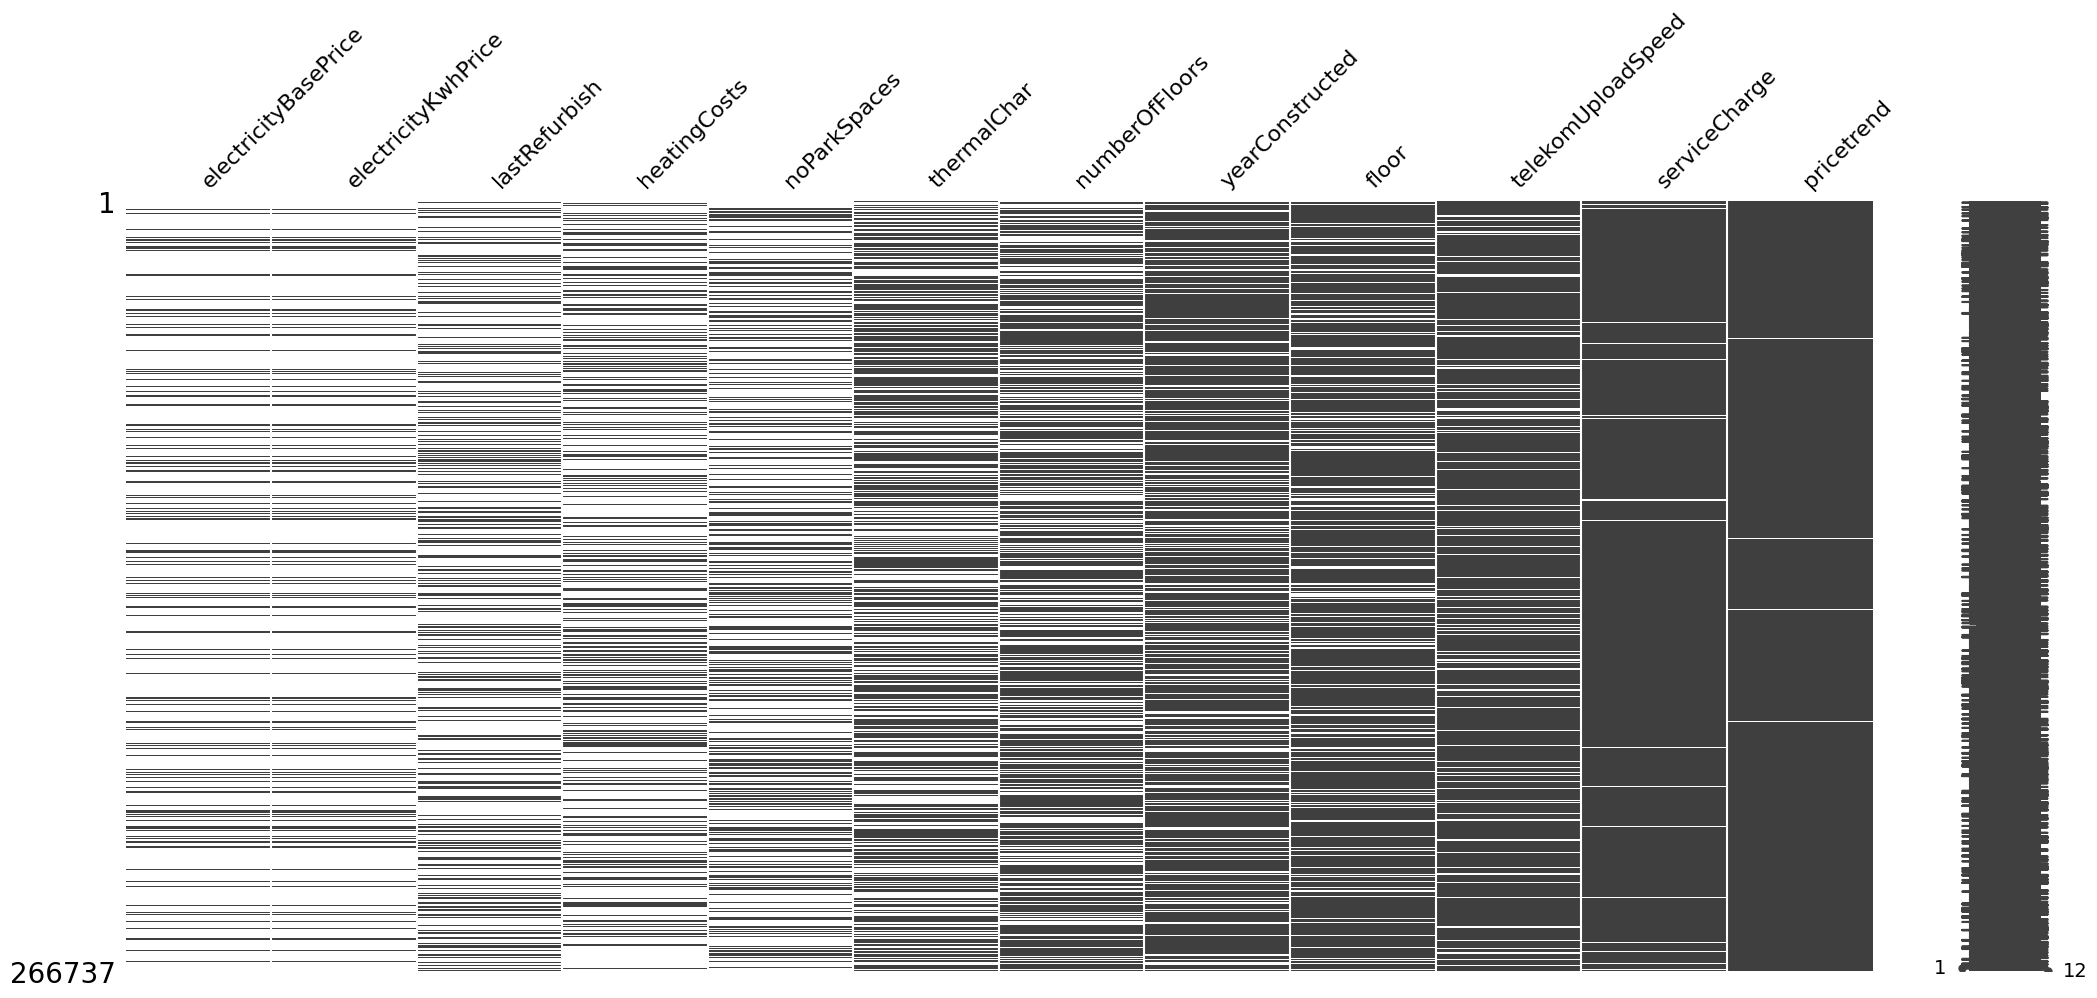

In [ ]:
msno.matrix(df[numerische_cols])

<Axes: >

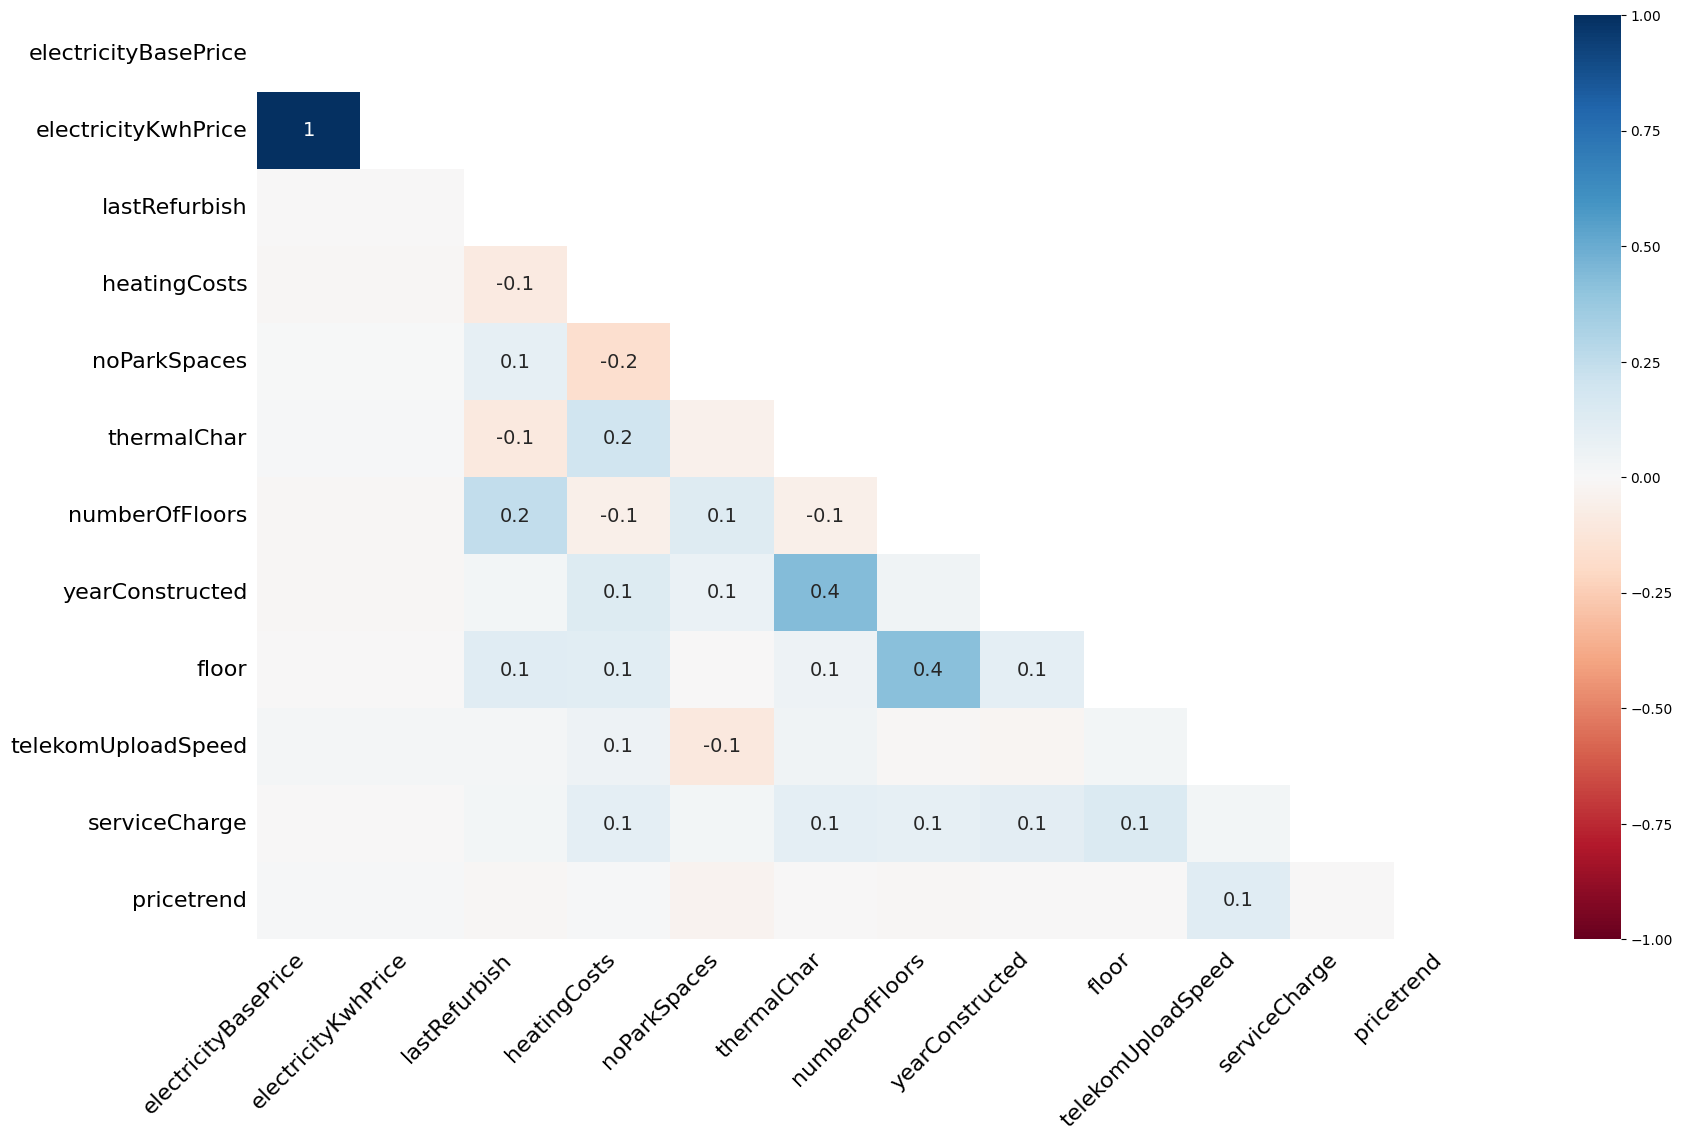

In [ ]:
msno.heatmap(df[numerische_cols])

In [ ]:
numerische_cols = [
    'electricityKwhPrice',
    'lastRefurbish',
    'heatingCosts',
    'noParkSpaces',
    'thermalChar',
    'numberOfFloors',
    'yearConstructed',
    'floor',
    'telekomUploadSpeed',
    'serviceCharge',
    'pricetrend'
]

<Axes: >

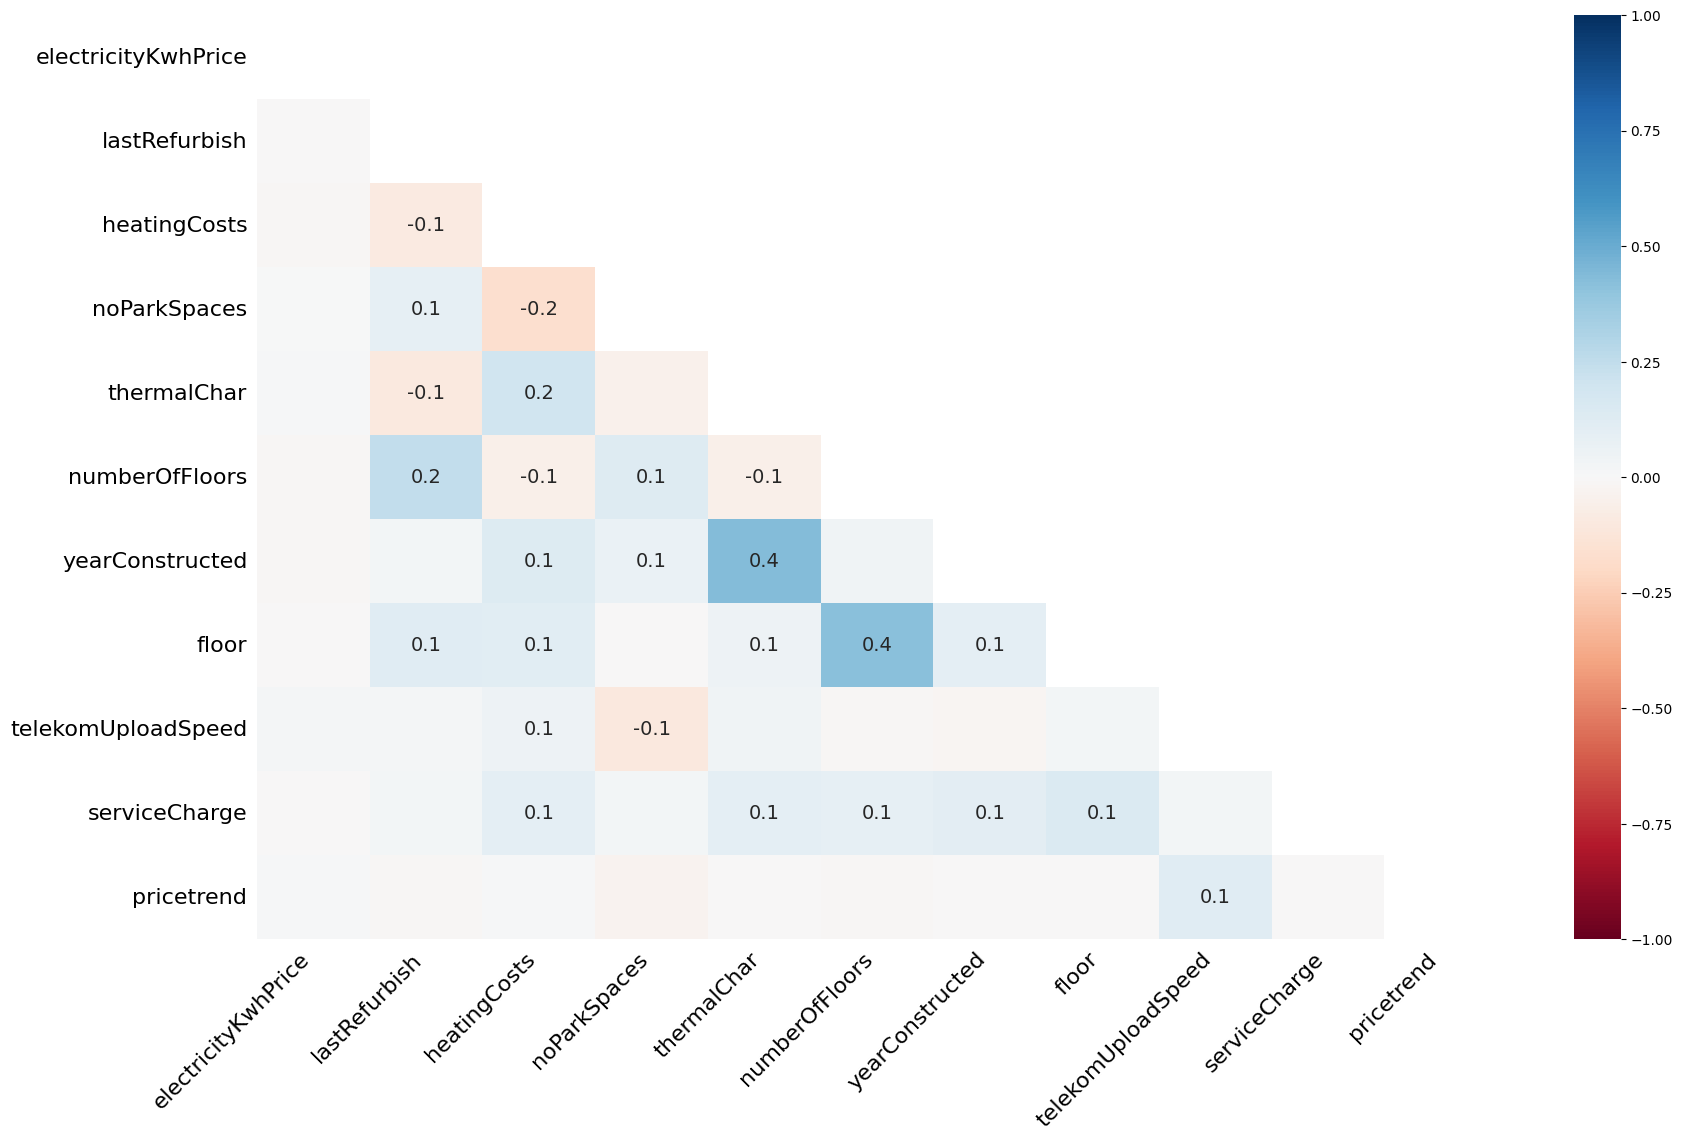

In [ ]:
msno.heatmap(df[numerische_cols])

In [ ]:
corr_matrix = df[numerische_cols].corr().abs()
corr_matrix

,electricityKwhPrice,lastRefurbish,heatingCosts,noParkSpaces,thermalChar,numberOfFloors,yearConstructed,floor,telekomUploadSpeed,serviceCharge,pricetrend
electricityKwhPrice,1.000000,0.102010,0.011226,0.000640,0.033399,0.007785,0.083831,0.001303,0.032345,0.098762,0.164465
lastRefurbish,0.102010,1.000000,0.012626,0.013345,0.009739,0.006707,0.128034,0.037301,0.008284,0.012825,0.173138
heatingCosts,0.011226,0.012626,1.000000,0.001286,0.002067,0.008574,0.010126,0.006264,0.000823,0.058556,0.027277
noParkSpaces,0.000640,0.013345,0.001286,1.000000,0.007928,0.005435,0.010126,0.003280,0.010391,0.005145,0.007883
thermalChar,0.033399,0.009739,0.002067,0.007928,1.000000,0.032820,0.318848,0.034808,0.002902,0.019526,0.003409
numberOfFloors,0.007785,0.006707,0.008574,0.005435,0.032820,1.000000,0.014270,0.120670,0.007564,0.007228,0.023054
yearConstructed,0.083831,0.128034,0.010126,0.010126,0.318848,0.014270,1.000000,0.015650,0.025373,0.032001,0.131740
floor,0.001303,0.037301,0.006264,0.003280,0.034808,0.120670,0.015650,1.000000,0.003468,0.002063,0.012046
telekomUploadSpeed,0.032345,0.008284,0.000823,0.010391,0.002902,0.007564,0.025373,0.003468,1.000000,0.010673,0.035139
serviceCharge,0.098762,0.012825,0.058556,0.005145,0.019526,0.007228,0.032001,0.002063,0.010673,1.000000,0.063492


In [ ]:
numerische_cols = [
    'electricityKwhPrice',
    'lastRefurbish',
    'heatingCosts',
    'noParkSpaces',
    'thermalChar',
    'numberOfFloors',
    'yearConstructed',
    'floor',
    'telekomUploadSpeed',
    'pricetrend'
]

In [ ]:
mt = MCARTest(method="little")
p_value = mt.little_mcar_test(df[numerische_cols])

print(f"Little's MCAR Test p-value: {p_value:.4f}")
print("MCAR abgelehnt" if p_value < 0.05 else "MCAR nicht abgelehnt")

Little's MCAR Test p-value: 0.0000
MCAR abgelehnt


In [ ]:
for col in numerische_cols:
    if df[col].isna().sum() > 0:
        hat_nan  = df[df[col].isna()]['baseRent']
        kein_nan = df[df[col].notna()]['baseRent']
        differenz = kein_nan.median() - hat_nan.median()

        print(f"{col}:")
        print(f"  Median mit NaN:    {hat_nan.median():.0f} €")
        print(f"  Median ohne NaN:   {kein_nan.median():.0f} €")
        print(f"  Differenz:         {differenz:.0f} €")
        print()

electricityKwhPrice:
  Median mit NaN:    494 €
  Median ohne NaN:   480 €
  Differenz:         -14 €

lastRefurbish:
  Median mit NaN:    460 €
  Median ohne NaN:   550 €
  Differenz:         90 €

heatingCosts:
  Median mit NaN:    550 €
  Median ohne NaN:   400 €
  Differenz:         -150 €

noParkSpaces:
  Median mit NaN:    420 €
  Median ohne NaN:   700 €
  Differenz:         280 €

thermalChar:
  Median mit NaN:    580 €
  Median ohne NaN:   441 €
  Differenz:         -139 €

numberOfFloors:
  Median mit NaN:    452 €
  Median ohne NaN:   510 €
  Differenz:         58 €

yearConstructed:
  Median mit NaN:    490 €
  Median ohne NaN:   492 €
  Differenz:         2 €

floor:
  Median mit NaN:    530 €
  Median ohne NaN:   480 €
  Differenz:         -50 €

telekomUploadSpeed:
  Median mit NaN:    680 €
  Median ohne NaN:   474 €
  Differenz:         -206 €

pricetrend:
  Median mit NaN:    750 €
  Median ohne NaN:   490 €
  Differenz:         -260 €



In [ ]:
kategoriale_cols = ['energyEfficiencyClass', 'petsAllowed', 'interiorQual',
                    'condition', 'firingTypes', 'heatingType', 'typeOfFlat', 'telekomTvOffer']

In [ ]:
for feature in kategoriale_cols:
    df['missing'] = df[feature].isna().astype(int)
    ct = pd.crosstab(df['missing'], df['baseRentRange'])

    stat, p, dof, expected = chi2_contingency(ct)

    hat_nan = df[df[feature].isna()]['baseRent'].median()
    kein_nan = df[df[feature].notna()]['baseRent'].median()
    differenz = kein_nan - hat_nan

    alpha = 0.05
    print(f"{feature}")
    print("p value is " + str(p))
    if p <= alpha:
        print('Dependent (reject H0)')
    else:
        print('Independent (H0 holds true)')
    print(f"Mit NaN werten {hat_nan}")
    print(f"Keine NaN werte median {kein_nan}")
    print(f" Differenz: {differenz}")

energyEfficiencyClass
p value is 1.1698248593884214e-76
Dependent (reject H0)
Mit NaN werten 489.0
Keine NaN werte median 500.0
 Differenz: 11.0
petsAllowed
p value is 1.4344463571673085e-302
Dependent (reject H0)
Mit NaN werten 460.0
Keine NaN werte median 510.0
 Differenz: 50.0
interiorQual
p value is 0.0
Dependent (reject H0)
Mit NaN werten 435.0
Keine NaN werte median 546.54
 Differenz: 111.53999999999996
condition
p value is 0.0
Dependent (reject H0)
Mit NaN werten 430.0
Keine NaN werte median 519.0
 Differenz: 89.0
firingTypes
p value is 4.986169327088596e-84
Dependent (reject H0)
Mit NaN werten 515.0
Keine NaN werte median 485.0
 Differenz: -30.0
heatingType
p value is 2.585551703090546e-95
Dependent (reject H0)
Mit NaN werten 470.0
Keine NaN werte median 495.0
 Differenz: 25.0
typeOfFlat
p value is 0.0
Dependent (reject H0)
Mit NaN werten 399.3
Keine NaN werte median 500.0
 Differenz: 100.69999999999999
telekomTvOffer
p value is 0.0
Dependent (reject H0)
Mit NaN werten 686.0
Ke

In [ ]:
# Schritt 1 – Kreuztabelle erstellen
ct = pd.crosstab(df['missing'], df['baseRentRange'])

# Schritt 2 – Chi-Squared auf dieser Tabelle
stat, p, dof, expected = chi2_contingency(ct)

In [ ]:
ct_pct = pd.crosstab(df['missing'], df['baseRentRange'], normalize='columns') * 100
print(ct_pct.round(1))

baseRentRange     1     2     3     4     5     6     7     8     9
missing                                                            
0              91.7  92.0  91.6  89.6  85.5  81.1  78.7  81.1  84.1
1               8.3   8.0   8.4  10.4  14.5  18.9  21.3  18.9  15.9


In [ ]:
df.drop(columns='missing', inplace=True)


In [ ]:
df.groupby('baseRentRange')['baseRent'].agg(['min', 'max', 'median', 'count'])

,min,max,median,count
baseRentRange,,,,
1,0.0,300.98,259.0,47667
2,301.0,400.98,350.0,54161
3,401.0,500.96,450.0,36929
4,501.0,600.98,550.0,25659
5,601.0,800.76,700.0,37764
6,801.0,1000.96,900.0,24007
7,1001.0,1500.90,1200.0,27242
8,1501.0,2000.00,1700.0,8179
9,2001.0,9999999.00,2500.0,5129


In [ ]:
df.groupby('baseRentRange')['yearConstructed'].median()

baseRentRange
1    1966.0
2    1964.0
3    1966.0
4    1971.0
5    1981.0
6    1995.0
7    2009.0
8    2009.0
9    2008.0
Name: yearConstructed, dtype: float64

In [ ]:
mar_features = [
    'noParkSpaces', 'pricetrend', 'telekomUploadSpeed',
    'heatingCosts', 'thermalChar', 'lastRefurbish',
    'numberOfFloors', 'floor',
    'interiorQual', 'typeOfFlat', 'condition',
    'petsAllowed', 'telekomTvOffer'
]


In [ ]:
df.describe()

,serviceCharge,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,noParkSpaces,baseRent,livingSpace,baseRentRange,noRooms,thermalChar,floor,numberOfFloors,heatingCosts,lastRefurbish,electricityBasePrice,electricityKwhPrice
count,259890.000000,264917.000000,233786.000000,2.265430e+05,210106.000000,92413.000000,2.667370e+05,266737.000000,266737.000000,266737.00000,161048.000000,215921.000000,169832.000000,84740.000000,79999.000000,46499.000000,46499.000000
mean,151.286078,3.390449,28.789247,9.020574e+02,1966.311362,1.328038,6.944882e+02,74.400042,3.766110,2.64215,114.870289,2.120271,3.567820,77.005984,2013.916149,89.116707,0.199751
std,309.403940,1.962771,16.343295,3.336935e+04,47.034186,8.386794,1.961319e+04,255.750235,2.212779,2.64239,61.572118,3.645393,6.396622,148.361114,10.978850,5.391203,0.009668
min,0.000000,-12.330000,1.000000,0.000000e+00,1000.000000,0.000000,0.000000e+00,0.000000,1.000000,1.00000,0.100000,-1.000000,0.000000,0.000000,1015.000000,71.430000,0.170500
25%,95.000000,2.000000,10.000000,4.700000e+02,1950.000000,1.000000,3.387000e+02,54.000000,2.000000,2.00000,79.000000,1.000000,2.000000,54.000000,2012.000000,90.760000,0.191500
50%,135.000000,3.390000,40.000000,6.500000e+02,1972.000000,1.000000,4.900000e+02,67.380000,3.000000,3.00000,107.000000,2.000000,3.000000,70.000000,2017.000000,90.760000,0.198500
75%,190.000000,4.570000,40.000000,9.837900e+02,1996.000000,1.000000,7.990000e+02,87.000000,5.000000,3.00000,140.600000,3.000000,4.000000,90.000000,2019.000000,90.760000,0.205500
max,146118.000000,14.920000,100.000000,1.575154e+07,2090.000000,2241.000000,9.999999e+06,111111.000000,9.000000,999.99000,1996.000000,999.000000,999.000000,12613.000000,2919.000000,90.760000,0.227600


In [ ]:
df.shape

(266737, 33)

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

#### 4.4.1. Kaltmiete (`baseRent`) – Zielvariable

Die Ad-hoc-Analyse zeigte unplausible Werte von 0 € sowie Beträge von fast 9.999.999 €.

* **Bereinigung nach unten (dieser Abschnitt):** Zeilen mit `baseRent <= 0` werden entfernt, da eine Miete von 0 € oder weniger nicht plausibel ist.
* **Bereinigung nach oben (später, Abschnitt 4.4.6):** Die Obergrenze wird nicht hier, sondern gemeinsam mit `livingSpace`, `noRooms` und `yearConstructed` über eine **log-transformierte IQR-Methode** (Faktor 3 statt der klassischen 1,5) behandelt. Durch die Log-Transformation wird der stark rechtsschiefen Verteilung der Mietpreise Rechnung getragen, bevor Quartile und IQR berechnet werden.

In [ ]:
df['baseRent'].sort_values(ascending=False).head(50)

262890    9999999.00
8403      1234567.00
258291    1000000.00
241966     120000.00
16718      120000.00
180590      39200.00
175677      30990.00
212257      20100.00
189176      20000.00
169900      19329.00
248727      17781.12
224263      16000.00
227439      16000.00
176312      15800.00
162568      15000.00
57107       13000.00
14115       12000.00
195243      12000.00
240097      12000.00
60953       12000.00
118182      12000.00
96039       11400.00
222227      11000.00
70926       10816.00
112315      10700.00
70977       10700.00
38084       10500.00
154045      10500.00
147314      10440.00
1648        10000.00
261482       9999.00
65401        9500.00
63951        9000.00
264725       9000.00
171041       8900.00
9052         8700.00
127900       8500.00
225452       8475.00
105060       8400.00
149876       8160.00
99577        8000.00
153874       7850.00
218941       7830.00
117548       7800.00
33682        7715.00
233493       7700.00
80472        7660.00
208435       

In [ ]:
df.dtypes

serviceCharge            float64
heatingType               object
telekomTvOffer            object
newlyConst                  bool
balcony                     bool
pricetrend               float64
telekomUploadSpeed       float64
totalRent                float64
yearConstructed          float64
noParkSpaces             float64
firingTypes               object
hasKitchen                  bool
geo_bln                   object
cellar                      bool
baseRent                 float64
livingSpace              float64
geo_krs                   object
condition                 object
interiorQual              object
petsAllowed               object
lift                        bool
baseRentRange              int64
typeOfFlat                object
noRooms                  float64
thermalChar              float64
floor                    float64
numberOfFloors           float64
garden                      bool
heatingCosts             float64
energyEfficiencyClass     object
lastRefurb

In [ ]:
df.isna().sum()

serviceCharge              6847
heatingType               44445
telekomTvOffer            32215
newlyConst                    0
balcony                       0
pricetrend                 1820
telekomUploadSpeed        32951
totalRent                 40194
yearConstructed           56631
noParkSpaces             174324
firingTypes               56465
hasKitchen                    0
geo_bln                       0
cellar                        0
baseRent                      0
livingSpace                   0
geo_krs                       0
condition                 68010
interiorQual             111739
petsAllowed              113537
lift                          0
baseRentRange                 0
typeOfFlat                36293
noRooms                       0
thermalChar              105689
floor                     50816
numberOfFloors            96905
garden                        0
heatingCosts             181997
energyEfficiencyClass    189603
lastRefurbish            186738
electric

**Weitere Anpassungen in dieser Feature-Selektion:**

* **`serviceCharge`:** Laut Datensatzbeschreibung umfasst dieses Feld auch Strom- und Internetkosten, die im Datensatz bereits über eigene Features (`electricityBasePrice`, `electricityKwhPrice`, `telekomUploadSpeed`, `telekomTvOffer`) abgebildet werden. Um Redundanz und ein dadurch erhöhtes Overfitting-Risiko zu vermeiden, wird `serviceCharge` an dieser Stelle entfernt.

* **`totalRent`:** Die Warmmiete setzt sich näherungsweise aus `baseRent` (Zielvariable) plus Nebenkosten zusammen. Da `totalRent` damit eine nahezu direkte Funktion der Zielvariable ist, würde die Einbeziehung zu *Data Leakage* führen. Das Feature wird daher entfernt.

* **`telekomHybridUploadSpeed`:** Mit 83,25 % fehlenden Werten (siehe Tabelle in Abschnitt 3.1) ist dies das am spärlichsten besetzte Feature im gesamten Datensatz. Eine verlässliche Imputation wäre hier kaum noch aussagekräftig, weshalb das Feature entfernt wird.

In [ ]:
df = df[[
         #'serviceCharge',
    'heatingType', 'telekomTvOffer',
       #'telekomHybridUploadSpeed',
    'newlyConst', 'balcony',
       'pricetrend', 'telekomUploadSpeed',
    #'totalRent',
    'yearConstructed',
         'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar',
         'baseRent',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
    'baseRentRange',
         'lift',
         'typeOfFlat',
    'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
         'garden',
         'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice',
        ]].copy()

In [ ]:
df[['baseRent', 'livingSpace', 'noRooms', 'floor', 'yearConstructed',
     'pricetrend', 'telekomUploadSpeed', 'numberOfFloors', 'thermalChar',
   'noParkSpaces', 'heatingCosts', 'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice']].describe()

,baseRent,livingSpace,noRooms,floor,yearConstructed,pricetrend,telekomUploadSpeed,numberOfFloors,thermalChar,noParkSpaces,heatingCosts,lastRefurbish,electricityBasePrice,electricityKwhPrice
count,2.667370e+05,266737.000000,266737.00000,215921.000000,210106.000000,264917.000000,233786.000000,169832.000000,161048.000000,92413.000000,84740.000000,79999.000000,46499.000000,46499.000000
mean,6.944882e+02,74.400042,2.64215,2.120271,1966.311362,3.390449,28.789247,3.567820,114.870289,1.328038,77.005984,2013.916149,89.116707,0.199751
std,1.961319e+04,255.750235,2.64239,3.645393,47.034186,1.962771,16.343295,6.396622,61.572118,8.386794,148.361114,10.978850,5.391203,0.009668
min,0.000000e+00,0.000000,1.00000,-1.000000,1000.000000,-12.330000,1.000000,0.000000,0.100000,0.000000,0.000000,1015.000000,71.430000,0.170500
25%,3.387000e+02,54.000000,2.00000,1.000000,1950.000000,2.000000,10.000000,2.000000,79.000000,1.000000,54.000000,2012.000000,90.760000,0.191500
50%,4.900000e+02,67.380000,3.00000,2.000000,1972.000000,3.390000,40.000000,3.000000,107.000000,1.000000,70.000000,2017.000000,90.760000,0.198500
75%,7.990000e+02,87.000000,3.00000,3.000000,1996.000000,4.570000,40.000000,4.000000,140.600000,1.000000,90.000000,2019.000000,90.760000,0.205500
max,9.999999e+06,111111.000000,999.99000,999.000000,2090.000000,14.920000,100.000000,999.000000,1996.000000,2241.000000,12613.000000,2919.000000,90.760000,0.227600


#### 4.4.2. Etage (`floor`) & Anzahl der Stockwerke (`numberOfFloors`)

Beide Features zeigten in der Ad-hoc-Analyse unplausible Extremwerte (bis zu 999). Als Obergrenze wird **47** gewählt – das höchste in Deutschland tatsächlich vorkommende Stockwerk (Wohnhochhaus), höhere Werte werden als Erfassungsfehler gewertet. Fehlende Werte (`NaN`) werden an dieser Stelle bewusst noch nicht entfernt, sondern erst in der späteren Imputation behandelt.

In [ ]:
obere_grenze = 47
df = df[(df['floor'] <= obere_grenze) | (df['floor'].isna())].copy()
df.shape

(266709, 31)

#### 4.4.3. Wohnfläche (`livingSpace`)

Eine Wohnfläche von 0 m² oder weniger ist nicht plausibel und wird entfernt. Der extreme Maximalwert (111.111 m²) wird hier noch nicht behandelt, da er zusammen mit den anderen numerischen Kernfeatures über die log-transformierte IQR-Methode in Abschnitt 4.4.6 gefiltert wird.

In [ ]:
df = df[(df['livingSpace'] > 0) | (df['livingSpace'].isna())].copy()

In [ ]:
df[['baseRent', 'livingSpace', 'noRooms', 'floor',
    'yearConstructed', 'pricetrend', 'telekomUploadSpeed',
    'numberOfFloors', 'thermalChar', 'noParkSpaces', 'heatingCosts',
    'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice']].describe()

,baseRent,livingSpace,noRooms,floor,yearConstructed,pricetrend,telekomUploadSpeed,numberOfFloors,thermalChar,noParkSpaces,heatingCosts,lastRefurbish,electricityBasePrice,electricityKwhPrice
count,2.666370e+05,266637.000000,266637.000000,215848.000000,210041.000000,264818.000000,233696.000000,169791.000000,161008.000000,92396.000000,84706.000000,79975.000000,46479.000000,46479.000000
mean,6.945321e+02,74.420674,2.642165,2.095947,1966.317195,3.390263,28.790041,3.568016,114.869898,1.328034,76.993686,2013.915536,89.116831,0.199751
std,1.961686e+04,255.795140,2.642691,1.662252,47.027221,1.962846,16.343066,6.397347,61.573670,8.387512,148.350917,10.979761,5.391018,0.009668
min,0.000000e+00,1.000000,1.000000,-1.000000,1000.000000,-12.330000,1.000000,0.000000,0.100000,0.000000,0.000000,1015.000000,71.430000,0.170500
25%,3.387000e+02,54.010000,2.000000,1.000000,1950.000000,2.000000,10.000000,2.000000,79.000000,1.000000,54.000000,2012.000000,90.760000,0.191500
50%,4.900000e+02,67.400000,3.000000,2.000000,1972.000000,3.390000,40.000000,3.000000,107.000000,1.000000,70.000000,2017.000000,90.760000,0.198500
75%,7.990000e+02,87.000000,3.000000,3.000000,1996.000000,4.570000,40.000000,4.000000,140.600000,1.000000,90.000000,2019.000000,90.760000,0.205500
max,9.999999e+06,111111.000000,999.990000,45.000000,2090.000000,14.920000,100.000000,999.000000,1996.000000,2241.000000,12613.000000,2919.000000,90.760000,0.227600


*(Rückbezug zu 4.4.1: Entfernen der unplausiblen `baseRent`-Werte <= 0 €.)*

In [ ]:
df = df[(df['baseRent'] > 0)]

*(Fortsetzung von 4.4.2: gleiche Obergrenze von 47 Stockwerken, jetzt angewendet auf `numberOfFloors`.)*

In [ ]:
obere_grenze = 47
df = df[(df['numberOfFloors'] <= obere_grenze) | df['numberOfFloors'].isna()]
df.shape

(266539, 31)

#### 4.4.4. Sanierungsjahr (`lastRefurbish`)

Ein Sanierungsjahr ist nur plausibel, wenn es (a) nicht in der Zukunft liegt (Obergrenze **2020**, ein Jahr nach Ende des Erhebungszeitraums) und (b) nicht vor dem Baujahr (`yearConstructed`) liegt – eine Sanierung kann logisch nicht vor dem Bau eines Gebäudes stattfinden.

In [ ]:
# 2020 = Letztes erhobenes Jahr
obere_grenze = 2020
df = df[
    (df['lastRefurbish'].isna()) |
    ((df['lastRefurbish'] <= obere_grenze) & (df['lastRefurbish'] >= df['yearConstructed']))
].copy()

In [ ]:
#Hardlimits entfernt mögliche Zukunftsbauten nicht
verdaechtig = df[(df['yearConstructed'] > 2020) & (df['lastRefurbish'].isna())]
print(f"Anzahl Zeilen mit yearConstructed > 2020 und fehlendem lastRefurbish: {len(verdaechtig)}")
print(verdaechtig['yearConstructed'].describe())

Anzahl Zeilen mit yearConstructed > 2020 und fehlendem lastRefurbish: 22
count      22.000000
mean     2025.272727
std        14.639093
min      2021.000000
25%      2021.000000
50%      2021.000000
75%      2022.000000
max      2090.000000
Name: yearConstructed, dtype: float64


Ein reines droppen von NaN werten würde zu einem stark reduzierten Datensatz führen.

In [ ]:
df_small = df.dropna().reset_index(drop=True).copy()

In [ ]:
df_small

,heatingType,telekomTvOffer,newlyConst,balcony,pricetrend,telekomUploadSpeed,yearConstructed,noParkSpaces,firingTypes,hasKitchen,...,noRooms,thermalChar,floor,numberOfFloors,garden,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice
0,central_heating,ONE_YEAR_FREE,False,True,3.95,40.0,1967.0,1.0,oil,False,...,3.0,78.00,1.0,3.0,False,75.00,C,2018.0,90.76,0.1915
1,gas_heating,ONE_YEAR_FREE,False,True,3.54,10.0,2016.0,1.0,gas,False,...,3.0,33.00,1.0,4.0,False,41.40,A,2016.0,90.76,0.1915
2,central_heating,ONE_YEAR_FREE,False,False,3.51,40.0,1927.0,1.0,gas,False,...,3.5,211.80,1.0,3.0,True,165.00,NO_INFORMATION,1996.0,90.76,0.1985
3,district_heating,ONE_YEAR_FREE,False,True,6.90,2.4,2016.0,1.0,district_heating,True,...,2.0,22.45,4.0,5.0,True,90.48,A_PLUS,2016.0,90.76,0.1985
4,central_heating,ONE_YEAR_FREE,False,True,0.00,40.0,1996.0,1.0,gas,False,...,2.0,102.40,1.0,3.0,False,60.00,D,2018.0,71.43,0.2276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,central_heating,ONE_YEAR_FREE,True,True,3.48,40.0,2018.0,0.0,gas,False,...,2.0,89.70,3.0,3.0,False,55.00,NO_INFORMATION,2018.0,90.76,0.1915
130,night_storage_heater,ONE_YEAR_FREE,False,True,4.69,2.4,1973.0,1.0,electricity,True,...,4.0,150.60,6.0,7.0,False,250.00,D,2018.0,90.76,0.1915
131,central_heating,ONE_YEAR_FREE,False,False,4.69,40.0,1924.0,1.0,natural_gas_light,False,...,4.0,129.00,1.0,2.0,False,110.00,NO_INFORMATION,2012.0,90.76,0.1915
132,gas_heating,ONE_YEAR_FREE,False,False,3.70,40.0,1900.0,5.0,gas,False,...,3.0,76.60,3.0,3.0,False,40.00,A,2007.0,90.76,0.1985


In [ ]:
total_rows = len(df)
missing_percentage = (df.isnull().sum() / total_rows) * 100
missing_percentage

heatingType              16.529209
telekomTvOffer           12.113823
newlyConst                0.000000
balcony                   0.000000
pricetrend                0.673743
telekomUploadSpeed       12.379973
yearConstructed          16.343143
noParkSpaces             65.427155
firingTypes              20.416677
hasKitchen                0.000000
geo_bln                   0.000000
cellar                    0.000000
baseRent                  0.000000
livingSpace               0.000000
geo_krs                   0.000000
condition                26.536938
interiorQual             43.463380
petsAllowed              43.438678
baseRentRange             0.000000
lift                      0.000000
typeOfFlat               13.858940
noRooms                   0.000000
thermalChar              37.127967
floor                    19.175970
numberOfFloors           37.101671
garden                    0.000000
heatingCosts             67.451969
energyEfficiencyClass    69.901907
lastRefurbish       

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

In [ ]:
df[[f'{feature}_missing' for feature in mar_features]] = df[mar_features].isna().astype(int).copy()

In [ ]:
df_temp = df['noParkSpaces'].dropna()

df_temp = (df_temp > 0).astype(int)  # hat Parkplatz?
df['hasParkingSpot'] = df_temp       # neues Feature

In [ ]:
for feature in numerische_cols:
    df[feature] = df[feature].fillna(df.groupby('baseRentRange')[feature].transform('median')).copy()

df['hasParkingSpot'] = df['hasParkingSpot'].fillna(df.groupby('baseRentRange')['hasParkingSpot'].transform('median'))

In [ ]:
pd.set_option('display.max_rows', None)
total_rows = len(df)
missing_percentage = (df.isnull().sum() / total_rows) * 100
missing_percentage

heatingType                   16.529209
telekomTvOffer                12.113823
newlyConst                     0.000000
balcony                        0.000000
pricetrend                     0.000000
telekomUploadSpeed             0.000000
yearConstructed                0.000000
noParkSpaces                   0.000000
firingTypes                   20.416677
hasKitchen                     0.000000
geo_bln                        0.000000
cellar                         0.000000
baseRent                       0.000000
livingSpace                    0.000000
geo_krs                        0.000000
condition                     26.536938
interiorQual                  43.463380
petsAllowed                   43.438678
baseRentRange                  0.000000
lift                           0.000000
typeOfFlat                    13.858940
noRooms                        0.000000
thermalChar                    0.000000
floor                          0.000000
numberOfFloors                 0.000000


In [ ]:
for feature in kategoriale_cols:
    df[feature] = df[feature].fillna(
    df.groupby('baseRentRange')[feature].transform(lambda x: x.mode()[0] if not x.mode().empty else 'unknown')).copy()


In [ ]:
pd.set_option('display.max_rows', None)
total_rows = len(df)
missing_percentage = (df.isnull().sum() / total_rows) * 100
missing_percentage

heatingType                    0.000000
telekomTvOffer                 0.000000
newlyConst                     0.000000
balcony                        0.000000
pricetrend                     0.000000
telekomUploadSpeed             0.000000
yearConstructed                0.000000
noParkSpaces                   0.000000
firingTypes                    0.000000
hasKitchen                     0.000000
geo_bln                        0.000000
cellar                         0.000000
baseRent                       0.000000
livingSpace                    0.000000
geo_krs                        0.000000
condition                      0.000000
interiorQual                   0.000000
petsAllowed                    0.000000
baseRentRange                  0.000000
lift                           0.000000
typeOfFlat                     0.000000
noRooms                        0.000000
thermalChar                    0.000000
floor                          0.000000
numberOfFloors                 0.000000


In [ ]:
df = df.drop(columns=['baseRentRange'])

In [ ]:
df_hardlimits = df.copy()
df_hardlimits.shape

(250986, 44)

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

#### 4.4.5. Multivariate Ausreißererkennung (Isolation Forest)

Zusätzlich zu den bisherigen univariaten Grenzwerten wird ein **Isolation Forest** auf die numerischen Kernfeatures (`baseRent`, `livingSpace`, `noRooms`, `floor`, `yearConstructed`) angewendet, um multivariate Ausreißer zu erkennen, die bei Betrachtung einzelner Spalten nicht auffallen würden (`contamination=0.05`). Der Zustand nach diesem Schritt wird zusätzlich als eigener Snapshot `df_isolation` gesichert.

In [ ]:
features_if = ['baseRent', 'livingSpace', 'noRooms', 'floor', 'yearConstructed']

iso = IsolationForest(contamination=0.05, random_state=42)
df['outlier'] = iso.fit_predict(df[features_if])

print(f"Outlier gefunden:  {(df['outlier'] == -1).sum()}")
print(f"Normale Werte:     {(df['outlier'] == 1).sum()}")
print(f"Das sind {(df['outlier'] == -1).mean()*100:.2f}% der Daten")

# RF Snapshot nach Isolation Forest
df = df[df['outlier'] == 1].drop(columns='outlier')
df_isolation = df.copy()

print(f"df_isolation: {df_isolation.shape}")

Outlier gefunden:  12550
Normale Werte:     238436
Das sind 5.00% der Daten
df_isolation: (238436, 44)


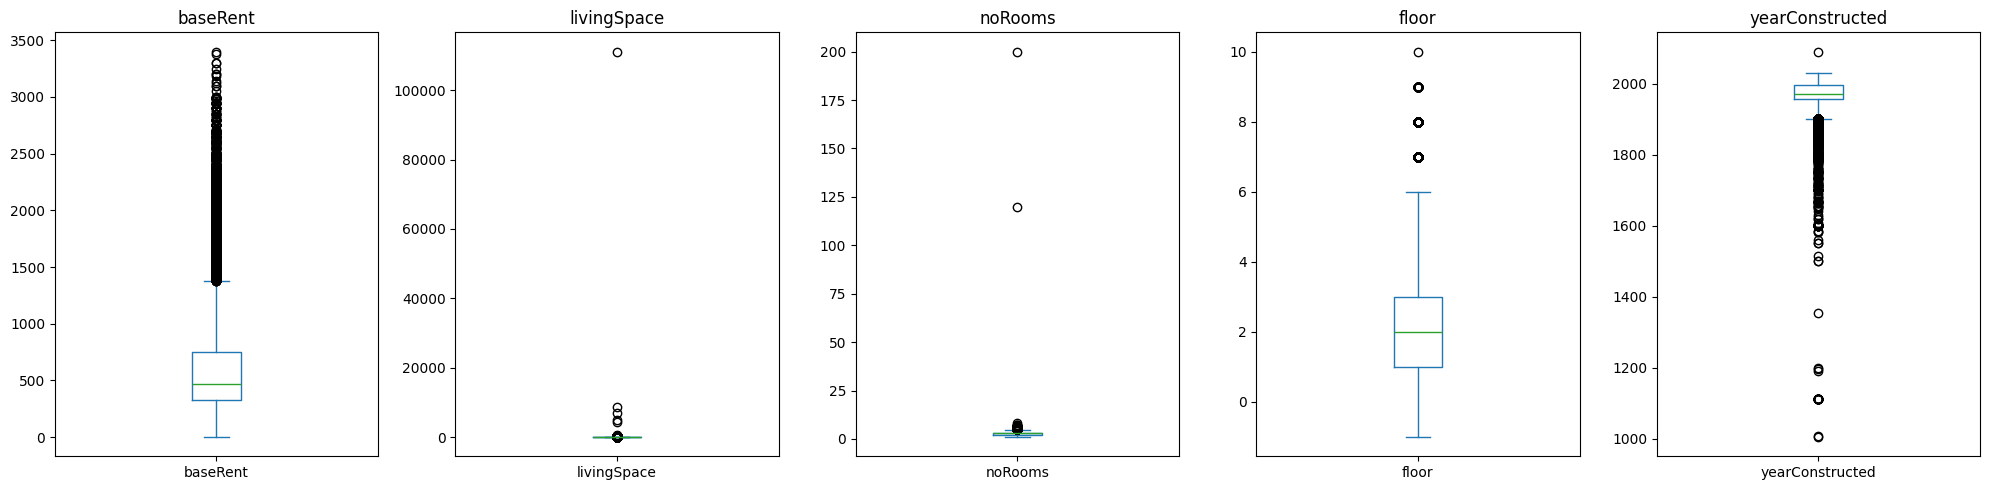

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
features = ['baseRent', 'livingSpace', 'noRooms', 'floor', 'yearConstructed', 'numberOfFloors']

for ax, feature in zip(axes, features):
    df[feature].plot(kind='box', ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
print(df[['baseRent', 'livingSpace', 'noRooms',
          'floor', 'yearConstructed', 'numberOfFloors']].describe())

            baseRent    livingSpace        noRooms          floor  \
count  238436.000000  238436.000000  238436.000000  238436.000000   
mean      590.099491      70.624841       2.555870       2.003858   
std       362.728607     230.319390       0.990035       1.241884   
min         1.000000       1.000000       1.000000      -1.000000   
25%       330.000000      53.840000       2.000000       1.000000   
50%       470.000000      66.000000       3.000000       2.000000   
75%       750.000000      84.000000       3.000000       3.000000   
max      3400.000000  111111.000000     200.000000      10.000000   

       yearConstructed  numberOfFloors  
count    238436.000000   238436.000000  
mean       1969.058938        3.366476  
std          37.292277        1.379584  
min        1005.000000        0.000000  
25%        1957.000000        3.000000  
50%        1971.000000        3.000000  
75%        1995.000000        4.000000  
max        2090.000000       43.000000  


In [ ]:
#Die kombination wird entfernt
verdaechtig = df[(df['yearConstructed'] > 2020) & (df['lastRefurbish'].isna())]
print(f"Anzahl Zeilen mit yearConstructed > 2020 und fehlendem lastRefurbish: {len(verdaechtig)}")
print(verdaechtig['yearConstructed'].describe())

Anzahl Zeilen mit yearConstructed > 2020 und fehlendem lastRefurbish: 0
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: yearConstructed, dtype: float64


In [ ]:
# Direkt auf yearConstructed prüfen, unabhängig davon, ob lastRefurbish (jetzt) NaN ist
#Es werden zukunftsbauten jedoch trotz aller Bereinigungsprozesse beibehalten
print((df['yearConstructed'] > 2020).sum())
print(df[df['yearConstructed'] > 2020][['yearConstructed', 'lastRefurbish']])

19
        yearConstructed  lastRefurbish
40198            2029.0         2017.0
46187            2021.0         2018.0
70993            2022.0         2017.0
79460            2021.0         2018.0
86948            2090.0         2018.0
96568            2021.0         2017.0
118215           2021.0         2017.0
124945           2021.0         2017.0
127432           2022.0         2018.0
133117           2021.0         2018.0
151020           2021.0         2018.0
177694           2021.0         2017.0
181091           2026.0         2018.0
196613           2021.0         2018.0
198711           2021.0         2018.0
208881           2021.0         2018.0
232718           2021.0         2017.0
238648           2026.0         2018.0
265659           2021.0         2018.0


#### 4.4.6. Log-transformierte IQR-Filterung

Als dritter Bereinigungsschritt wird für `baseRent`, `livingSpace`, `noRooms` und `yearConstructed` eine IQR-Filterung auf den **logarithmierten** Werten durchgeführt (Faktor **3** statt der üblichen 1,5, um bei dieser bereits mehrfach bereinigten Verteilung nicht zu aggressiv zu filtern). Dies ist der in Abschnitt 4.4.1 angekündigte Schritt zur Behandlung der oberen `baseRent`-Grenze.

In [ ]:
features = ['baseRent', 'livingSpace', 'noRooms', 'yearConstructed']
for feature in features:
    df = df.reset_index(drop=True)
    log_vals = np.log(df[feature])
    Q1 = log_vals.quantile(0.25)
    Q3 = log_vals.quantile(0.75)
    IQR = Q3 - Q1

    untere_grenze = np.exp(Q1 - 3 * IQR)
    obere_grenze = np.exp(Q3 + 3 * IQR)

    vorher = len(df)
    df = df[(log_vals >= Q1 - 3 * IQR) & (log_vals <= Q3 + 3 * IQR)]
    nachher = len(df)

    print(f"--- {feature} ---")
    print(f"Obere Grenze:    {obere_grenze:.2f}")
    print(f"Untere Grenze:   {untere_grenze:.2f}")
    print(f"Entfernt:        {vorher - nachher} Zeilen")
    print(f"Entfernt:        {vorher} ")
    print(f"Entfernt:        {nachher} ")
    print(f"Min nach Filter: {df[feature].min():.2f}")
    print(f"Max nach Filter: {df[feature].max():.2f}")
    print()

--- baseRent ---
Obere Grenze:    8804.47
Untere Grenze:   28.11
Entfernt:        38 Zeilen
Entfernt:        238436 
Entfernt:        238398 
Min nach Filter: 29.75
Max nach Filter: 3400.00

--- livingSpace ---
Obere Grenze:    319.01
Untere Grenze:   14.18
Entfernt:        340 Zeilen
Entfernt:        238398 
Entfernt:        238058 
Min nach Filter: 14.18
Max nach Filter: 293.00

--- noRooms ---
Obere Grenze:    10.13
Untere Grenze:   0.59
Entfernt:        2 Zeilen
Entfernt:        238058 
Entfernt:        238056 
Min nach Filter: 1.00
Max nach Filter: 8.00

--- yearConstructed ---
Obere Grenze:    2113.48
Untere Grenze:   1847.29
Entfernt:        388 Zeilen
Entfernt:        238056 
Entfernt:        237668 
Min nach Filter: 1848.00
Max nach Filter: 2090.00



In [ ]:
verdaechtig = df[(df['yearConstructed'] > 2020) & (df['lastRefurbish'].isna())]
print(f"Anzahl Zeilen mit yearConstructed > 2020 und fehlendem lastRefurbish: {len(verdaechtig)}")
print(verdaechtig['yearConstructed'].describe())

Anzahl Zeilen mit yearConstructed > 2020 und fehlendem lastRefurbish: 0
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: yearConstructed, dtype: float64


In [ ]:
log_vals = np.log(df['yearConstructed'])
print(f"Q1: {log_vals.quantile(0.25):.3f} → {np.exp(log_vals.quantile(0.25)):.0f}")
print(f"Q3: {log_vals.quantile(0.75):.3f} → {np.exp(log_vals.quantile(0.75)):.0f}")
print(f"IQR: {(log_vals.quantile(0.75) - log_vals.quantile(0.25)):.3f}")

Q1: 7.579 → 1957
Q3: 7.598 → 1995
IQR: 0.019


In [ ]:
df_encoded = pd.get_dummies(df, dummy_na=True, dtype='int')

In [ ]:
corr_matrix = df_encoded.corr()

In [ ]:
rent_corr = corr_matrix['baseRent'].sort_values(ascending=False)

In [ ]:
rent_corr.to_csv('korrelation_zur_miete_alle.csv')

In [ ]:
# Für jedes Feature: hat irgendeine Kategorie r > 0.05?
for feature in mar_features:
    feature_cols = [col for col in rent_corr.index if col.startswith(f'{feature}_')]
    max_corr = rent_corr[feature_cols].abs().max()
    print(f"{feature}: max |r| = {max_corr:.4f} → {'behalten' if max_corr >= 0.05 else 'droppen'}")

noParkSpaces: max |r| = 0.3160 → behalten
pricetrend: max |r| = 0.0495 → droppen
telekomUploadSpeed: max |r| = 0.1404 → behalten
heatingCosts: max |r| = 0.1865 → behalten
thermalChar: max |r| = 0.1280 → behalten
lastRefurbish: max |r| = 0.0535 → behalten
numberOfFloors: max |r| = 0.0604 → behalten
floor: max |r| = 0.0473 → droppen
interiorQual: max |r| = 0.6352 → behalten
typeOfFlat: max |r| = 0.1751 → behalten
condition: max |r| = 0.4714 → behalten
petsAllowed: max |r| = 0.1828 → behalten
telekomTvOffer: max |r| = 0.1431 → behalten


In [ ]:
# Alle Features im Dataset anzeigen
print("Numerische Features:")
print(df.select_dtypes(include='number').columns.tolist())
print()
print("Kategoriale Features:")
print(df.select_dtypes(include='object').columns.tolist())
print()
print("Boolean Features:")
print(df.select_dtypes(include='bool').columns.tolist())

Numerische Features:
['pricetrend', 'telekomUploadSpeed', 'yearConstructed', 'noParkSpaces', 'baseRent', 'livingSpace', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'heatingCosts', 'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'noParkSpaces_missing', 'pricetrend_missing', 'telekomUploadSpeed_missing', 'heatingCosts_missing', 'thermalChar_missing', 'lastRefurbish_missing', 'numberOfFloors_missing', 'floor_missing', 'interiorQual_missing', 'typeOfFlat_missing', 'condition_missing', 'petsAllowed_missing', 'telekomTvOffer_missing', 'hasParkingSpot']

Kategoriale Features:
['heatingType', 'telekomTvOffer', 'firingTypes', 'geo_bln', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'typeOfFlat', 'energyEfficiencyClass']

Boolean Features:
['newlyConst', 'balcony', 'hasKitchen', 'cellar', 'lift', 'garden']


In [ ]:
# 1. Numerische Korrelation
num_cols = ['pricetrend', 'telekomUploadSpeed', 'yearConstructed',
            'noParkSpaces', 'livingSpace', 'noRooms', 'thermalChar',
            'floor', 'numberOfFloors', 'heatingCosts', 'lastRefurbish',
            'electricityBasePrice', 'electricityKwhPrice', 'hasParkingSpot']

korr_num = df[num_cols + ['baseRent']].corr()['baseRent'].drop('baseRent')
print("Numerische Korrelationen:")
print(korr_num.sort_values(key=abs, ascending=False).round(4))

print()

# 2. Boolean Korrelation
bool_cols = ['newlyConst', 'balcony', 'hasKitchen', 'cellar', 'lift', 'garden']
korr_bool = df[bool_cols + ['baseRent']].corr()['baseRent'].drop('baseRent')
print("Boolean Korrelationen:")
print(korr_bool.sort_values(key=abs, ascending=False).round(4))

Numerische Korrelationen:
livingSpace             0.6570
pricetrend              0.4775
noRooms                 0.3927
lastRefurbish           0.3738
yearConstructed         0.3475
electricityKwhPrice    -0.2825
thermalChar            -0.2362
heatingCosts            0.1529
telekomUploadSpeed      0.0535
floor                  -0.0427
numberOfFloors         -0.0327
electricityBasePrice    0.0112
noParkSpaces            0.0053
hasParkingSpot          0.0031
Name: baseRent, dtype: float64

Boolean Korrelationen:
newlyConst    0.3441
lift          0.3294
hasKitchen    0.2850
balcony       0.2694
garden        0.0319
cellar        0.0100
Name: baseRent, dtype: float64


In [ ]:
# MAR Features die wir behalten müssen
mar_features = [
    'pricetrend', 'telekomUploadSpeed',
    'heatingCosts', 'thermalChar', 'lastRefurbish',
    'numberOfFloors', 'floor',
    'interiorQual', 'typeOfFlat', 'condition',
    'petsAllowed', 'telekomTvOffer'
]

# Numerische + Boolean Korrelationen zusammen
korr_alle = pd.concat([korr_num, korr_bool])

# Automatisch droppen: r < 0.05 UND nicht MAR
drop_cols = [
    feature for feature, wert in korr_alle.items()
    if abs(wert) < 0.05
]

print(f"Features die rausfallen: {drop_cols}")

df = df.drop(columns=drop_cols, errors='ignore')
df_isolation = df_isolation.drop(columns=drop_cols, errors='ignore')
df_hardlimits = df_hardlimits.drop(columns=drop_cols, errors='ignore')

print(f"df Shape:         {df.shape}")
print(f"df_isolation Shape:      {df_isolation.shape}")
print(f"df_hardlimits Shape: {df_hardlimits.shape}")

Features die rausfallen: ['noParkSpaces', 'floor', 'numberOfFloors', 'electricityBasePrice', 'hasParkingSpot', 'cellar', 'garden']
df Shape:         (237668, 37)
df_isolation Shape:      (238436, 37)
df_hardlimits Shape: (250986, 37)


In [ ]:
# Kategoriale Features einzeln mit get_dummies testen
kat_cols = ['heatingType', 'firingTypes', 'condition',
            'interiorQual', 'typeOfFlat', 'petsAllowed',
            'telekomTvOffer', 'energyEfficiencyClass', 'geo_bln']

for feature in kat_cols:
    # Temporär encoden
    dummies = pd.get_dummies(df[feature], prefix=feature, drop_first=True)
    # Korrelation zur baseRent
    korr_temp = dummies.corrwith(df['baseRent'])
    max_korr = korr_temp.abs().max()
    print(f"{feature}: max |r| = {max_korr:.4f} → {'behalten' if max_korr >= 0.05 else 'droppen'}")

heatingType: max |r| = 0.2877 → behalten
firingTypes: max |r| = 0.0894 → behalten
condition: max |r| = 0.3198 → behalten
interiorQual: max |r| = 0.6352 → behalten
typeOfFlat: max |r| = 0.1751 → behalten
petsAllowed: max |r| = 0.1828 → behalten
telekomTvOffer: max |r| = 0.0354 → droppen
energyEfficiencyClass: max |r| = 0.5800 → behalten
geo_bln: max |r| = 0.2668 → behalten


In [ ]:
df.describe()

,pricetrend,telekomUploadSpeed,yearConstructed,baseRent,livingSpace,noRooms,thermalChar,heatingCosts,lastRefurbish,electricityKwhPrice,...,heatingCosts_missing,thermalChar_missing,lastRefurbish_missing,numberOfFloors_missing,floor_missing,interiorQual_missing,typeOfFlat_missing,condition_missing,petsAllowed_missing,telekomTvOffer_missing
count,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,...,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000,237668.000000
mean,3.323725,30.246323,1969.489574,590.758001,70.144346,2.556925,110.586263,77.102884,2015.138790,0.199818,...,0.670713,0.366377,0.749100,0.373996,0.193745,0.438721,0.139375,0.268387,0.432494,0.119288
std,1.931290,15.733643,34.664762,362.931297,25.312889,0.870226,49.842556,88.317320,4.471939,0.004757,...,0.469955,0.481815,0.433532,0.483864,0.395232,0.496232,0.346338,0.443121,0.495423,0.324128
min,-12.330000,1.000000,1848.000000,35.000000,14.180000,1.000000,0.100000,0.000000,1898.000000,0.170500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.950000,10.000000,1957.000000,330.000000,53.970000,2.000000,86.000000,65.000000,2015.000000,0.198500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.330000,40.000000,1971.000000,470.000000,66.000000,3.000000,107.000000,75.000000,2017.000000,0.198500,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,40.000000,1995.000000,750.000000,84.000000,3.000000,119.700000,85.000000,2018.000000,0.198500,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,14.920000,100.000000,2090.000000,3400.000000,293.000000,8.000000,1996.000000,12613.000000,2020.000000,0.227600,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# floor + numberOfFloors entfernen
# Aber Flags behalten!
drop_low_corr = ['floor', 'numberOfFloors']

df = df.drop(columns=drop_low_corr, errors='ignore')
df_isolation = df_isolation.drop(columns=drop_low_corr, errors='ignore')
df_hardlimits = df_hardlimits.drop(columns=drop_low_corr, errors='ignore')

In [ ]:
# Korrelation der Flags zu baseRent
flag_cols = [col for col in df.columns if '_missing' in col]
korr_flags = df[flag_cols + ['baseRent']].corr()['baseRent'].drop('baseRent')
print(korr_flags.sort_values(key=abs, ascending=False).round(4))

noParkSpaces_missing         -0.3160
heatingCosts_missing          0.1865
telekomTvOffer_missing        0.1431
telekomUploadSpeed_missing    0.1404
thermalChar_missing           0.1280
interiorQual_missing         -0.1203
condition_missing            -0.0878
typeOfFlat_missing           -0.0709
numberOfFloors_missing       -0.0604
lastRefurbish_missing        -0.0535
pricetrend_missing            0.0495
floor_missing                 0.0473
petsAllowed_missing          -0.0416
Name: baseRent, dtype: float64


In [ ]:
total_rows = len(df)
missing = df.isna().sum()
missing_pct = (missing / total_rows * 100).round(2)

result = pd.DataFrame({
    'Absolut': missing,
    'Prozent': missing_pct
})

# Alle Features anzeigen, auch die ohne NaN
print(result.sort_values('Prozent', ascending=False).to_string())

                            Absolut  Prozent
heatingType                       0      0.0
telekomTvOffer                    0      0.0
newlyConst                        0      0.0
balcony                           0      0.0
pricetrend                        0      0.0
telekomUploadSpeed                0      0.0
yearConstructed                   0      0.0
firingTypes                       0      0.0
hasKitchen                        0      0.0
geo_bln                           0      0.0
baseRent                          0      0.0
livingSpace                       0      0.0
geo_krs                           0      0.0
condition                         0      0.0
interiorQual                      0      0.0
petsAllowed                       0      0.0
lift                              0      0.0
typeOfFlat                        0      0.0
noRooms                           0      0.0
thermalChar                       0      0.0
heatingCosts                      0      0.0
energyEffi

In [ ]:
drop_cols = [
    'floor_missing',      # ← beide weg
    'pricetrend_missing', # Flag unter 0.05, Feature bleibt
    'petsAllowed_missing' # Flag unter 0.05, Feature bleibt
]

df = df.drop(columns=drop_cols, errors='ignore')
df_isolation = df_isolation.drop(columns=drop_cols, errors='ignore')
df_hardlimits = df_hardlimits.drop(columns=drop_cols, errors='ignore')

In [ ]:
for col in [c for c in df.columns if '_missing' in c]:
    print(f"{col}: unique={df[col].unique()}, sum={df[col].sum()}")

noParkSpaces_missing: unique=[0 1], sum=156897
telekomUploadSpeed_missing: unique=[0 1], sum=28976
heatingCosts_missing: unique=[1 0], sum=159407
thermalChar_missing: unique=[0 1], sum=87076
lastRefurbish_missing: unique=[1 0], sum=178037
numberOfFloors_missing: unique=[0 1], sum=88887
interiorQual_missing: unique=[0 1], sum=104270
typeOfFlat_missing: unique=[0 1], sum=33125
condition_missing: unique=[0 1], sum=63787
telekomTvOffer_missing: unique=[0 1], sum=28351


### 7. Datenexport

Am Ende werden drei parallel entstandene Bereinigungsstände jeweils **mit** und **ohne** Imputation als CSV exportiert:

* `df_clean_outlier_*`: univariate Grenzwerte + Isolation Forest + log-transformierte IQR-Filterung (alle drei Schritte kombiniert)
* `df_clean_isolation_*`: Snapshot direkt nach dem Isolation Forest (Abschnitt 4.4.5)
* `df_clean_hardlimits_*`: Snapshot mit ausschließlich den manuellen Grenzwerten aus 4.4.1–4.4.4, vor Isolation Forest und log-IQR-Filterung

**Hinweis:** Aufgrund eines unvollständigen vorherigen Durchlaufs wurden beide Features nun final entfernt.
Begründungen und Anpassungen: `geo_bln`: Wird zusätzlich final entfernt, da Bundesländer mit nur 16 verschiedenen Ausprägungen zu ungenau sind. `telekomTvOffer`: max |r| = 0.0354 $\rightarrow$ wird aufgrund der geringen Korrelation gedroppt.

In [ ]:
drop_final = ['telekomTvOffer', 'geo_bln']
df_outlier = df.drop(columns=drop_final, errors='ignore')
df_isolation = df_isolation.drop(columns=drop_final, errors='ignore')
df_hardlimits = df_hardlimits.drop(columns=drop_final, errors='ignore')


#RAW Versionen (NaN zurücksetzen)
numerische_impute = ['heatingCosts', 'lastRefurbish', 'floor']
kategoriale_impute = ['interiorQual', 'typeOfFlat', 'condition']

df_outlier_raw = df_outlier.copy()
df_isolation_raw = df_isolation.copy()
df_hardlimits_raw = df_hardlimits.copy()

for feature in numerische_impute + kategoriale_impute:
    for dataset in [df_outlier_raw, df_isolation_raw, df_hardlimits_raw]:
        if f'{feature}_missing' in dataset.columns:
            dataset.loc[dataset[f'{feature}_missing'] == 1, feature] = np.nan

# MIT Imputation (df_outlier, df_isolation, df_hardlimits haben noch imputierte Werte)
df_outlier.to_csv('df_clean_outlier_imputed.csv', index=False)
df_isolation.to_csv('df_clean_isolation_imputed.csv', index=False)
df_hardlimits.to_csv('df_clean_hardlimits_imputed.csv', index=False)

# OHNE Imputation
df_outlier_raw.to_csv('df_clean_outlier_raw.csv', index=False)
df_isolation_raw.to_csv('df_clean_isolation_raw.csv', index=False)
df_hardlimits_raw.to_csv('df_clean_hardlimits_raw.csv', index=False)

print("MIT Imputation:")
print(f"  df_clean_outlier_imputed:  {df_outlier.shape} | NaN: {df_outlier.isna().sum().sum()}")
print(f"  df_clean_isolation_imputed:      {df_isolation.shape} | NaN: {df_isolation.isna().sum().sum()}")
print(f"  df_clean_hardlimits_imputed: {df_hardlimits.shape} | NaN: {df_hardlimits.isna().sum().sum()}")
print()
print("OHNE Imputation:")
print(f"  df_clean_outlier_raw:  {df_outlier_raw.shape} | NaN: {df_outlier_raw.isna().sum().sum()}")
print(f"  df_clean_isolation_raw:      {df_isolation_raw.shape} | NaN: {df_isolation_raw.isna().sum().sum()}")
print(f"  df_clean_hardlimits_raw: {df_hardlimits_raw.shape} | NaN: {df_hardlimits_raw.isna().sum().sum()}")

MIT Imputation:
  df_clean_outlier_imputed:  (237668, 32) | NaN: 0
  df_clean_isolation_imputed:      (238436, 32) | NaN: 0
  df_clean_hardlimits_imputed: (250986, 32) | NaN: 0

OHNE Imputation:
  df_clean_outlier_raw:  (237668, 32) | NaN: 538626
  df_clean_isolation_raw:      (238436, 32) | NaN: 540511
  df_clean_hardlimits_raw: (250986, 32) | NaN: 566354
